In [52]:
import os
import pandas as pd
import numpy as np
from IPython.display import HTML

# مسیر پوشه شامل فایل‌های داده
input_dir = 'Northwind Database - Cleaned/'

# فهرست تمامی جدول‌های مورد بررسی
files = [
    'Categories.csv', 'CustomerCustomerDemo.csv', 'CustomerDemographics.csv',
    'Customers.csv', 'Employees.csv', 'EmployeeTerritories.csv',
    'Order_Details.csv', 'Orders.csv', 'Products.csv',
    'Region.csv', 'Shippers.csv', 'Suppliers.csv', 'Territories.csv'
]

# تعریف مسیرهای پرکاربرد
DATA_ROOT = input_dir
CATEGORIES_PATH = os.path.join(DATA_ROOT, 'Categories.csv')
CUSTOMERS_PATH = os.path.join(DATA_ROOT, 'Customers.csv')
EMPLOYEES_PATH = os.path.join(DATA_ROOT, 'Employees.csv')

# مقادیری که به عنوان داده گمشده در نظر گرفته می‌شوند
DEFAULT_NA_VALUES = [
    '', ' ', '  ', '\t',
    'NA', 'N/A', 'NULL', 'null', 'None',
    '-', '?', '--'
]

# لیست ذخیره نتایج تحلیل هر ستون
all_columns_data = []

print("Phase 1: Identifying Missing Values Percentage Per Column...")
print("=" * 80)

# پیمایش تمامی فایل‌های داده
for fname in files:

    # ایجاد مسیر کامل فایل
    path = os.path.join(input_dir, fname)

    # در صورت نبود فایل، از آن عبور کن
    if not os.path.exists(path):
        print(f"[SKIP] {fname} - File not found")
        continue

    # خواندن فایل و شناسایی مقادیر گمشده
    df = pd.read_csv(
        path,
        keep_default_na=True,
        na_values=DEFAULT_NA_VALUES
    )

    # تبدیل سلول‌های خالی یا دارای فاصله به مقدار گمشده
    df = df.replace(r'^\s*$', pd.NA, regex=True)

    # تعداد کل رکوردهای جدول
    n_rows = len(df)

    # محاسبه آمار مقادیر گمشده برای هر ستون
    for col in df.columns:

        missing_count = df[col].isna().sum()
        missing_pct = (missing_count / n_rows * 100) if n_rows > 0 else 0
        available_pct = 100 - missing_pct

        # ذخیره نتایج برای گزارش نهایی
        all_columns_data.append({
            'Table': fname.replace('.csv', ''),
            'Column': col,
            'Total_Rows': n_rows,
            'Missing_Count': int(missing_count),
            'Missing_Percentage': round(missing_pct, 2),
            'Available_Percentage': round(available_pct, 2),
            'Data_Type': str(df[col].dtype)
        })

# تبدیل نتایج به DataFrame برای ادامه تحلیل
df_columns = pd.DataFrame(all_columns_data)

Phase 1: Identifying Missing Values Percentage Per Column...


In [53]:
# HTML Report
# Use the full column list, including columns with no missing values
html_content = f"""
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Phase 1: Missing Values Analysis</title>
    <style>
        body {{
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            background: #1a1a1a;
            margin: 0;
            padding: 20px;
        }}
        .container {{
            max-width: 1600px;
            margin: 0 auto;
            background: #242424;
            border-radius: 10px;
            box-shadow: 0 10px 30px rgba(0,0,0,0.5);
            overflow: hidden;
            border: 1px solid #3a3a3a;
        }}
        .header {{
            background: #1a1a1a;
            border-bottom: 2px solid #00d4ff;
            color: #00d4ff;
            padding: 30px;
            text-align: center;
        }}
        .header h1 {{
            margin: 0;
            font-size: 32px;
            font-weight: 600;
            color: #00d4ff;
        }}
        .header p {{
            margin: 10px 0 0 0;
            opacity: 0.7;
            font-size: 16px;
            color: #b0b0b0;
        }}
        .content {{
            padding: 30px;
        }}
        .stats-grid {{
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(200px, 1fr));
            gap: 20px;
            margin-bottom: 30px;
        }}
        .stat-card {{
            background: #2a2a2a;
            border: 2px solid #00d4ff;
            color: #00d4ff;
            padding: 20px;
            border-radius: 8px;
            text-align: center;
        }}
        .stat-card h3 {{
            margin: 0;
            font-size: 14px;
            opacity: 0.8;
            font-weight: 600;
            color: #b0b0b0;
        }}
        .stat-card .number {{
            font-size: 32px;
            font-weight: bold;
            margin-top: 10px;
            color: #00d4ff;
        }}
        .section-title {{
            font-size: 22px;
            font-weight: 600;
            color: #00d4ff;
            margin-bottom: 20px;
            border-bottom: 3px solid #00d4ff;
            padding-bottom: 10px;
        }}
        table {{
            width: 100%;
            border-collapse: collapse;
            margin-bottom: 20px;
            font-size: 13px;
        }}
        table thead {{
            background: #2a2a2a;
            border-bottom: 2px solid #00d4ff;
        }}
        table th {{
            padding: 12px;
            text-align: left;
            font-weight: 600;
            color: #00d4ff;
        }}
        table td {{
            padding: 12px;
            border-bottom: 1px solid #3a3a3a;
            color: #e0e0e0;
        }}
        table tr:hover {{
            background: #2a2a2a;
        }}
        .missing-high {{
            background: #8b0000;
            color: #ff6b6b;
            font-weight: 600;
            border-radius: 4px;
            padding: 4px 8px;
        }}
        .missing-medium {{
            background: #8b5000;
            color: #ffb84d;
            font-weight: 600;
            border-radius: 4px;
            padding: 4px 8px;
        }}
        .missing-low {{
            background: #005000;
            color: #6bff6b;
            font-weight: 600;
            border-radius: 4px;
            padding: 4px 8px;
        }}
        .available-high {{
            background: #005000;
            color: #6bff6b;
            font-weight: 600;
            border-radius: 4px;
            padding: 4px 8px;
        }}
        .available-medium {{
            background: #8b5000;
            color: #ffb84d;
            font-weight: 600;
            border-radius: 4px;
            padding: 4px 8px;
        }}
        .available-low {{
            background: #8b0000;
            color: #ff6b6b;
            font-weight: 600;
            border-radius: 4px;
            padding: 4px 8px;
        }}
        .progress-bar {{
            width: 100%;
            height: 20px;
            background: #3a3a3a;
            border-radius: 10px;
            overflow: hidden;
            margin-top: 5px;
            display: flex;
            border: 1px solid #4a4a4a;
        }}
        .progress-missing {{
            height: 100%;
            background: linear-gradient(90deg, #ff4444 0%, #dd0000 100%);
            display: flex;
            align-items: center;
            justify-content: center;
            color: white;
            font-size: 10px;
            font-weight: bold;
        }}
        .progress-available {{
            height: 100%;
            background: linear-gradient(90deg, #44ff44 0%, #00cc00 100%);
            display: flex;
            align-items: center;
            justify-content: center;
            color: black;
            font-size: 10px;
            font-weight: bold;
        }}
        .footer {{
            background: #2a2a2a;
            padding: 20px;
            text-align: center;
            color: #b0b0b0;
            border-top: 2px solid #00d4ff;
            font-size: 12px;
        }}
    </style>
</head>
<body>
    <div class="container">
        <div class="header">
            <h1>📊 Phase 1: Missing Values Analysis</h1>
            <p> وضعیت کامل هر ستون و درصد missing آن در تمام فایل‌ها </p>
        </div>
        
        <div class="content">
            <div class="stats-grid">
                <div class="stat-card">
                    <h3>کل ستون‌ها</h3>
                    <div class="number">{len(df_columns)}</div>
                </div>
                <div class="stat-card">
                    <h3>تعداد فایل‌ها</h3>
                    <div class="number">{df_columns['Table'].nunique()}</div>
                </div>
                <div class="stat-card">
                    <h3>ستون‌های بدون missing</h3>
                    <div class="number">{len(df_columns[df_columns['Missing_Count'] == 0])}</div>
                </div>
                <div class="stat-card">
                    <h3>ستون‌های دارای missing</h3>
                    <div class="number">{len(df_columns[df_columns['Missing_Count'] > 0])}</div>
                </div>
            </div>

            <div class="section-title">گزارش درصد مقادیر گمشده</div>
            <table>
                <thead>
                    <tr>
                        <th>فایل</th>
                        <th>ستون</th>
                        <th>نوع داده</th>
                        <th>کل ردیف‌ها</th>
                        <th>تعداد missing</th>
                        <th>٪ missing</th>
                        <th>٪ موجود</th>
                        <th>کامل بودن</th>
                    </tr>
                </thead>
                <tbody>
"""

for _, row in df_columns.iterrows():
    missing_pct = row['Missing_Percentage']
    available_pct = row['Available_Percentage']
    
    if missing_pct > 30:
        missing_badge = f'<span class="missing-high">{missing_pct:.2f}%</span>'
    elif missing_pct > 10:
        missing_badge = f'<span class="missing-medium">{missing_pct:.2f}%</span>'
    else:
        missing_badge = f'<span class="missing-low">{missing_pct:.2f}%</span>'
    
    if available_pct == 100:
        available_badge = f'<span class="available-high">{available_pct:.2f}%</span>'
    elif available_pct > 90:
        available_badge = f'<span class="available-high">{available_pct:.2f}%</span>'
    elif available_pct > 70:
        available_badge = f'<span class="available-medium">{available_pct:.2f}%</span>'
    else:
        available_badge = f'<span class="available-low">{available_pct:.2f}%</span>'
    
    html_content += f"""
                    <tr>
                        <td><strong>{row['Table']}</strong></td>
                        <td>{row['Column']}</td>
                        <td><code>{row['Data_Type']}</code></td>
                        <td>{row['Total_Rows']}</td>
                        <td>{row['Missing_Count']}</td>
                        <td>{missing_badge}</td>
                        <td>{available_badge}</td>
                        <td>
                            <div class="progress-bar">
                                <div class="progress-available" style="width: {available_pct * 2}%; min-width: 2px;">
                                    {available_pct:.0f}%
                                </div>
                                <div class="progress-missing" style="width: {missing_pct * 2}%; min-width: 2px;">
                                    {missing_pct:.0f}%
                                </div>
                            </div>
                        </td>
                    </tr>
"""

html_content += """
                </tbody>
            </table>
        </div>
        
        <div class="footer">
            <strong>راهنما:</strong><br>
            🔴 missing بیشتر از ۳۰٪: مشکل مهم<br>
            🟠 missing بین ۱۰ تا ۳۰٪: نیاز به بررسی<br>
            🟢 missing کمتر از ۱۰٪: وضعیت خوب<br><br>
            ✓ ۱۰۰٪ موجود: ستون کامل است
        </div>
    </div>
</body>
</html>
"""

# Display HTML
display(HTML(html_content))

print("\n✓ HTML Report Generated Successfully!")

فایل,ستون,نوع داده,کل ردیف‌ها,تعداد missing,٪ missing,٪ موجود,کامل بودن
Categories,CategoryID,int64,9,0,0.00%,100.00%,100% 0%
Categories,CategoryName,object,9,0,0.00%,100.00%,100% 0%
Categories,Description,object,9,4,44.44%,55.56%,56% 44%
Categories,Picture,object,9,0,0.00%,100.00%,100% 0%
CustomerCustomerDemo,CustomerID,object,0,0,0.00%,100.00%,100% 0%
CustomerCustomerDemo,CustomerTypeID,object,0,0,0.00%,100.00%,100% 0%
CustomerDemographics,CustomerTypeID,object,0,0,0.00%,100.00%,100% 0%
CustomerDemographics,CustomerDesc,object,0,0,0.00%,100.00%,100% 0%
Customers,CustomerID,object,93,0,0.00%,100.00%,100% 0%
Customers,CompanyName,object,93,0,0.00%,100.00%,100% 0%



✓ HTML Report Generated Successfully!


In [54]:
def print_high_missing_columns(limit_pct=30):

    # لیست ذخیره ستون‌هایی که درصد مقادیر گمشده آن‌ها از حد مجاز بیشتر است
    report = []

    # بررسی تمامی فایل‌های داده
    for fname in files:

        path = os.path.join(input_dir, fname)

        # عبور از فایل‌های موجود نبود
        if not os.path.exists(path):
            print(f"[SKIP] {fname} - File not found")
            continue

        # خواندن داده‌ها
        df = pd.read_csv(
            path,
            keep_default_na=True,
            na_values= DEFAULT_NA_VALUES)

        # تبدیل سلول‌های خالی به مقدار گمشده
        df = df.replace(r'^\s*$', pd.NA, regex=True)

        total_rows = len(df)

        # صرف‌نظر از جدول‌های خالی
        if total_rows == 0:
            continue

        # محاسبه تعداد و درصد مقادیر گمشده هر ستون
        missing_count = df.isna().sum()
        missing_pct = 100 * missing_count / total_rows

        # انتخاب ستون‌هایی که از آستانه تعیین‌شده بیشتر هستند
        high_missing = missing_pct[missing_pct > limit_pct].sort_values(ascending=False)

        # ذخیره نتایج برای گزارش
        for col, pct in high_missing.items():
            report.append({
                'file': fname,
                'column': col,
                'missing_count': int(missing_count[col]),
                'missing_pct': round(pct, 2)
            })

    # در صورت نبود ستون بحرانی، پیام مناسب نمایش داده می‌شود
    if len(report) == 0:
        print(f"No columns with more than {limit_pct}% missing values found.")
        return

    # نمایش نتایج به صورت جدول
    report_df = pd.DataFrame(report)

    print(f"\nColumns with >{limit_pct}% missing values:")
    print(report_df.to_string(
        index=False,
        columns=['file', 'column', 'missing_count', 'missing_pct']
    ))


# اجرای تابع با آستانه ۳۰ درصد
print_high_missing_columns(30)


Columns with >30% missing values:
          file          column  missing_count  missing_pct
Categories.csv     Description              4        44.44
 Customers.csv          Region             61        65.59
 Customers.csv             Fax             31        33.33
 Employees.csv          Region              5        50.00
    Orders.csv      ShipRegion            511        61.20
  Products.csv QuantityPerUnit             26        32.91
 Suppliers.csv        HomePage             28        87.50
 Suppliers.csv          Region             22        68.75
 Suppliers.csv             Fax             22        68.75


In [55]:
file_path = 'Northwind Database - Cleaned//Categories.csv'

# بررسی وجود فایل
if os.path.exists(file_path):

    # بارگذاری جدول دسته‌بندی محصولات
    df_categories = pd.read_csv(file_path)

    # تعریف توضیحات استاندارد هر دسته بر اساس مستندات رسمی Northwind
    official_docs_mapping = {
        'Beverages': 'Soft drinks, coffees, teas, beers, and ales',
        'Condiments': 'Sweet and savory sauces, relishes, spreads, and seasonings',
        'Confections': 'Desserts, candies, and sweet breads',
        'Dairy Products': 'Cheeses',
        'Grains/Cereals': 'Breads, crackers, pasta, and cereal',
        'Meat/Poultry': 'Prepared meats',
        'Produce': 'Dried fruit and bean curd',
        'Seafood': 'Seaweed and fish'
    }

    # حذف فاصله‌های اضافی از نام دسته‌ها برای جلوگیری از عدم تطابق
    category_key = df_categories['CategoryName'].astype(str).str.strip()

    # استخراج توضیح متناظر هر دسته
    mapped_desc = category_key.map(official_docs_mapping)

    # محاسبه تعداد مقادیر گمشده قبل از اصلاح
    before_fill = df_categories['Description'].isna().sum()

    # تکمیل فقط مقادیر خالی بدون تغییر اطلاعات موجود
    df_categories['Description'] = df_categories['Description'].fillna(mapped_desc)

    # محاسبه تعداد مقادیر گمشده پس از اصلاح
    after_fill = df_categories['Description'].isna().sum()

    # ذخیره تغییرات در فایل
    df_categories.to_csv(file_path, index=False)

    print(f"✓ Missing descriptions filled successfully: {before_fill - after_fill} rows updated.")

    # نمایش دسته‌هایی که همچنان توضیح ندارند
    if after_fill > 0:
        print(f"⚠️ Still {after_fill} missing Description rows remain. بررسی کنید نام دسته‌ها در این ردیف‌ها صحیح است:")
        print(df_categories[df_categories['Description'].isna()][['CategoryName']].to_string(index=False))

else:
    print("Error: File not found.")

✓ Missing descriptions filled successfully: 4 rows updated.


In [56]:
# فقط فایل‌های موردنظر برای پاک‌سازی پردازش می‌شوند
target_files = ['Customers.csv', 'Employees.csv', 'Orders.csv']

print("Phase 2: Cleaning Region and Fax in Customers, Employees, and Orders...")
print("=" * 80)

# پیمایش فایل‌های انتخاب‌شده
for fname in target_files:
    path = os.path.join(input_dir, fname)

    # بررسی وجود فایل
    if not os.path.exists(path):
        print(f"[SKIP] {fname} - File not found")
        continue

    # بارگذاری داده‌ها
    df = pd.read_csv(
        path,
        keep_default_na=True,
        na_values=DEFAULT_NA_VALUES
    )

    # تبدیل سلول‌های خالی به مقدار گمشده
    df = df.replace(r'^\s*$', pd.NA, regex=True)

    print(f"\nProcessing {fname}:")

    # تکمیل مقادیر گمشده جدول Customers
    if fname == 'Customers.csv':

        if 'Region' in df.columns:
            before_region = int(df['Region'].isna().sum())
            df['Region'] = df['Region'].fillna('Unknown')
            after_region = int(df['Region'].isna().sum())
            print(f"   - Region: {before_region} -> {after_region} missing values")
        else:
            print("   - Column 'Region' not found.")

        if 'Fax' in df.columns:
            before_fax = int(df['Fax'].isna().sum())
            df['Fax'] = df['Fax'].fillna('No Fax')
            after_fax = int(df['Fax'].isna().sum())
            print(f"   - Fax: {before_fax} -> {after_fax} missing values")
        else:
            print("   - Column 'Fax' not found.")

    # تکمیل مقادیر گمشده جدول Employees
    elif fname == 'Employees.csv':

        if 'Region' in df.columns:
            before_region = int(df['Region'].isna().sum())
            df['Region'] = df['Region'].fillna('Unknown')
            after_region = int(df['Region'].isna().sum())
            print(f"   - Region: {before_region} -> {after_region} missing values")
        else:
            print("   - Column 'Region' not found.")

    # تکمیل مقادیر گمشده جدول Orders
    elif fname == 'Orders.csv':

        if 'ShipRegion' in df.columns:
            before_region = int(df['ShipRegion'].isna().sum())
            df['ShipRegion'] = df['ShipRegion'].fillna('Unknown')
            after_region = int(df['ShipRegion'].isna().sum())
            print(f"   - ShipRegion: {before_region} -> {after_region} missing values")
        else:
            print("   - Column 'ShipRegion' not found.")

    # ذخیره فایل پس از اعمال تغییرات
    df.to_csv(path, index=False)

    print(f"✓ {fname} cleaned and saved successfully.")

print("\n" + "=" * 80)
print("Cleaning process completed successfully!")

Phase 2: Cleaning Region and Fax in Customers, Employees, and Orders...

Processing Customers.csv:
   - Region: 61 -> 0 missing values
   - Fax: 31 -> 0 missing values
✓ Customers.csv cleaned and saved successfully.

Processing Employees.csv:
   - Region: 5 -> 0 missing values
✓ Employees.csv cleaned and saved successfully.

Processing Orders.csv:
   - ShipRegion: 511 -> 0 missing values
✓ Orders.csv cleaned and saved successfully.

Cleaning process completed successfully!


In [57]:
# مسیر فایل جدول Suppliers
file_path = 'Northwind Database - Cleaned//Suppliers.csv'

if os.path.exists(file_path):

    # بارگذاری داده‌ها و شناسایی مقادیر گمشده
    df_suppliers = pd.read_csv(
        file_path,
        keep_default_na=True,
        na_values=DEFAULT_NA_VALUES
    )

    # تبدیل سلول‌های خالی به مقدار گمشده
    df_suppliers = df_suppliers.replace(r'^\s*$', pd.NA, regex=True)

    # نمایش وضعیت ستون‌ها قبل از اعمال تغییرات
    print("Suppliers Table Status (Before Cleaning):")
    print(f" - Region: {df_suppliers['Region'].isna().sum()} missing values")
    print(f" - Fax: {df_suppliers['Fax'].isna().sum()} missing values")
    print(f" - HomePage: {df_suppliers['HomePage'].isna().sum()} missing values")
    print("-" * 50)

    # جایگزینی مقادیر گمشده با مقادیر مناسب
    df_suppliers['Region'] = df_suppliers['Region'].fillna('Unknown')
    df_suppliers['Fax'] = df_suppliers['Fax'].fillna('No Fax')
    df_suppliers['HomePage'] = df_suppliers['HomePage'].fillna('No Website')

    # بررسی نتیجه پاک‌سازی
    print("Suppliers Table Status (After Cleaning):")
    print(f" - Region: {df_suppliers['Region'].isna().sum()} missing values")
    print(f" - Fax: {df_suppliers['Fax'].isna().sum()} missing values")
    print(f" - HomePage: {df_suppliers['HomePage'].isna().sum()} missing values")

    # ذخیره فایل پس از اعمال تغییرات
    df_suppliers.to_csv(file_path, index=False)

    print("\nSuppliers.csv cleaned and saved successfully!")

else:
    print(f"Error: File not found: {file_path}")

Suppliers Table Status (Before Cleaning):
 - Region: 22 missing values
 - Fax: 22 missing values
 - HomePage: 28 missing values
--------------------------------------------------
Suppliers Table Status (After Cleaning):
 - Region: 0 missing values
 - Fax: 0 missing values
 - HomePage: 0 missing values

Suppliers.csv cleaned and saved successfully!


In [58]:
# مسیر فایل جدول Products
file_path = 'Northwind Database - Cleaned//Products.csv'

if os.path.exists(file_path):

    # بارگذاری داده‌ها و شناسایی مقادیر گمشده
    df_products = pd.read_csv(
        file_path,
        keep_default_na=True,
        na_values=DEFAULT_NA_VALUES
    )

    # تبدیل سلول‌های خالی به مقدار گمشده
    df_products = df_products.replace(r'^\s*$', pd.NA, regex=True)

    # نمایش تعداد مقادیر گمشده قبل از اصلاح
    missing_before = df_products['QuantityPerUnit'].isna().sum()

    print("Products Table Status (Before Cleaning):")
    print(f" - QuantityPerUnit: {missing_before} missing values")
    print("-" * 50)

    # جایگزینی مقادیر گمشده با مقدار مناسب
    df_products['QuantityPerUnit'] = df_products['QuantityPerUnit'].fillna('Not Specified')

    # بررسی نتیجه پاک‌سازی
    missing_after = df_products['QuantityPerUnit'].isna().sum()

    print("Products Table Status (After Cleaning):")
    print(f" - QuantityPerUnit: {missing_after} missing values")

    # ذخیره فایل پس از اعمال تغییرات
    df_products.to_csv(file_path, index=False)

    print("\nProducts.csv cleaned and saved successfully!")

else:
    print(f"Error: File not found: {file_path}")

Products Table Status (Before Cleaning):
 - QuantityPerUnit: 26 missing values
--------------------------------------------------
Products Table Status (After Cleaning):
 - QuantityPerUnit: 0 missing values

Products.csv cleaned and saved successfully!


In [59]:
# مسیر پوشه داده‌های پاک‌سازی‌شده
input_dir = 'Northwind Database - Cleaned/'

# فهرست تمامی جدول‌های پایگاه داده
files = [
    'Categories.csv', 'CustomerCustomerDemo.csv', 'CustomerDemographics.csv',
    'Customers.csv', 'Employees.csv', 'EmployeeTerritories.csv',
    'Order_Details.csv', 'Orders.csv', 'Products.csv',
    'Region.csv', 'Shippers.csv', 'Suppliers.csv', 'Territories.csv'
]

print("Text Column Detection Report")
print("=" * 85)

# بررسی تمامی فایل‌ها
for fname in files:

    path = os.path.join(input_dir, fname)

    # بررسی وجود فایل
    if os.path.exists(path):

        # بارگذاری جدول
        df = pd.read_csv(path)

        # شناسایی ستون‌های متنی
        text_columns = df.select_dtypes(include=['object']).columns.tolist()

        # استخراج نام جدول
        table_name = fname.replace('.csv', '')

        # نمایش ستون‌های متنی هر جدول
        if text_columns:

            print(f"Table: {table_name} (Total Columns: {len(df.columns)})")
            print("   Text Columns:")

            for col in text_columns:
                print(f"      - {col} ({df[col].dtype})")

            print("-" * 60)

        else:
            print(f"Table: {table_name} -> No text columns found.")
            print("-" * 60)

    else:
        print(f"[ERROR] File not found: {fname}")

Text Column Detection Report
Table: Categories (Total Columns: 4)
   Text Columns:
      - CategoryName (object)
      - Description (object)
      - Picture (object)
------------------------------------------------------------
Table: CustomerCustomerDemo (Total Columns: 2)
   Text Columns:
      - CustomerID (object)
      - CustomerTypeID (object)
------------------------------------------------------------
Table: CustomerDemographics (Total Columns: 2)
   Text Columns:
      - CustomerTypeID (object)
      - CustomerDesc (object)
------------------------------------------------------------
Table: Customers (Total Columns: 11)
   Text Columns:
      - CustomerID (object)
      - CompanyName (object)
      - ContactName (object)
      - ContactTitle (object)
      - Address (object)
      - City (object)
      - Region (object)
      - PostalCode (object)
      - Country (object)
      - Phone (object)
      - Fax (object)
------------------------------------------------------------
T

In [60]:
# تابع استانداردسازی داده‌های متنی
def normalize_text(df):

    # شناسایی ستون‌های متنی
    text_cols = df.select_dtypes(include=['object']).columns

    # ستون‌هایی که نباید روی آن‌ها عملیات متنی انجام شود
    exclude_cols = [
        'Picture', 'Photo',
        'CustomerID', 'CustomerTypeID',
        'BirthDate', 'HireDate', 'OrderDate',
        'RequiredDate', 'ShippedDate',
        'HomePage', 'PhotoPath'
    ]

    # اعمال عملیات استانداردسازی روی ستون‌های متنی
    for col in text_cols:

        # صرف‌نظر از ستون‌های مستثنی
        if col in exclude_cols:
            continue

        # حذف فاصله‌های اضافی و یکسان‌سازی متن
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].str.replace(r'\s+', ' ', regex=True)
        df[col] = df[col].str.title()

        # تبدیل مقادیر متنی معادل داده گمشده به مقدار استاندارد
        df[col] = df[col].replace({
            '': pd.NA,
            'Nan': pd.NA,
            'None': pd.NA,
            '<Na>': pd.NA
        })

    return df


print("Starting text normalization process...")
print("=" * 70)

# اعمال استانداردسازی روی تمامی جدول‌ها
for fname in files:

    path = os.path.join(input_dir, fname)

    if os.path.exists(path):

        # بارگذاری داده‌ها
        df = pd.read_csv(path)

        # استانداردسازی داده‌های متنی
        df = normalize_text(df)

        # ذخیره تغییرات
        df.to_csv(path, index=False)

        print(f"[DONE] {fname} normalized and saved successfully.")

    else:
        print(f"[ERROR] File not found: {fname}")

print("=" * 70)
print("Text normalization completed successfully for all database tables.")

Starting text normalization process...
[DONE] Categories.csv normalized and saved successfully.
[DONE] CustomerCustomerDemo.csv normalized and saved successfully.
[DONE] CustomerDemographics.csv normalized and saved successfully.
[DONE] Customers.csv normalized and saved successfully.
[DONE] Employees.csv normalized and saved successfully.
[DONE] EmployeeTerritories.csv normalized and saved successfully.
[DONE] Order_Details.csv normalized and saved successfully.
[DONE] Orders.csv normalized and saved successfully.
[DONE] Products.csv normalized and saved successfully.
[DONE] Region.csv normalized and saved successfully.
[DONE] Shippers.csv normalized and saved successfully.
[DONE] Suppliers.csv normalized and saved successfully.
[DONE] Territories.csv normalized and saved successfully.
Text normalization completed successfully for all database tables.


In [61]:
# حذف ردیف‌های تکراری
def remove_duplicates(df):

    # ایجاد یک نسخه کمکی برای تشخیص رکوردهای تکراری
    norm = df.copy()

    # شناسایی ستون‌های متنی
    text_cols = df.select_dtypes(include=['object']).columns

    # ستون‌هایی که نباید در فرآیند نرمال‌سازی تغییر کنند
    exclude_cols = [
        'Picture', 'Photo',
        'BirthDate', 'HireDate',
        'OrderDate', 'RequiredDate', 'ShippedDate'
    ]

    # استانداردسازی متن برای تشخیص دقیق‌تر رکوردهای تکراری
    for col in text_cols:

        if col in exclude_cols:
            continue

        norm[col] = norm[col].astype(str).str.lower().str.strip()

    # شناسایی رکوردهای تکراری
    dup_mask = norm.duplicated(keep='first')
    n_dup = int(dup_mask.sum())

    # حذف رکوردهای تکراری
    if n_dup > 0:

        df_cleaned = df[~dup_mask].reset_index(drop=True)

        return df_cleaned, n_dup

    return df, n_dup


print("Starting duplicate row detection and removal...")
print("=" * 75)

# بررسی تمامی جدول‌ها
for fname in files:

    path = os.path.join(input_dir, fname)

    if os.path.exists(path):

        # بارگذاری جدول
        df_table = pd.read_csv(path)

        # حذف رکوردهای تکراری
        df_cleaned, num_duplicates = remove_duplicates(df_table)

        if num_duplicates > 0:

            print(f"[REMOVED] {fname}: {num_duplicates} duplicate row(s) removed.")

            # ذخیره جدول اصلاح‌شده
            df_cleaned.to_csv(path, index=False)

        else:
            print(f"[OK] {fname}: No duplicate rows found.")

    else:
        print(f"[ERROR] File not found: {fname}")

print("=" * 75)
print("Duplicate removal completed successfully for all database tables.")

Starting duplicate row detection and removal...


[REMOVED] Categories.csv: 1 duplicate row(s) removed.
[OK] CustomerCustomerDemo.csv: No duplicate rows found.
[OK] CustomerDemographics.csv: No duplicate rows found.
[REMOVED] Customers.csv: 2 duplicate row(s) removed.
[OK] Employees.csv: No duplicate rows found.
[REMOVED] EmployeeTerritories.csv: 3 duplicate row(s) removed.
[REMOVED] Order_Details.csv: 9 duplicate row(s) removed.
[OK] Orders.csv: No duplicate rows found.
[REMOVED] Products.csv: 1 duplicate row(s) removed.
[REMOVED] Region.csv: 1 duplicate row(s) removed.
[REMOVED] Shippers.csv: 1 duplicate row(s) removed.
[REMOVED] Suppliers.csv: 3 duplicate row(s) removed.
[REMOVED] Territories.csv: 4 duplicate row(s) removed.
Duplicate removal completed successfully for all database tables.


In [62]:
# بارگذاری جدول جزئیات سفارش
df_details = pd.read_csv(
    'Northwind Database - Cleaned//Order_Details.csv'
)

# شناسایی رکوردهای دارای قیمت واحد یا تعداد نامعتبر
invalid_unit_price = df_details[df_details['UnitPrice'] <= 0]
invalid_quantity = df_details[df_details['Quantity'] <= 0]

# نمایش خلاصه نتایج بررسی
print("Order_Details Data Validation Report")
print("=" * 60)
print(f"Rows with zero or negative UnitPrice : {len(invalid_unit_price)}")
print(f"Rows with zero or negative Quantity  : {len(invalid_quantity)}")
print("=" * 60)

# نمایش رکوردهای نامعتبر در صورت وجود
if len(invalid_unit_price) > 0 or len(invalid_quantity) > 0:

    print("Invalid records found:")

    invalid_rows = df_details[
        (df_details['UnitPrice'] <= 0) |
        (df_details['Quantity'] <= 0)
    ]

    print(invalid_rows)

else:
    print("No invalid records found. All UnitPrice and Quantity values are positive.")

Order_Details Data Validation Report
Rows with zero or negative UnitPrice : 6
Rows with zero or negative Quantity  : 10
Invalid records found:
      OrderID  ProductID  UnitPrice  Quantity  Discount
87      10281         24       3.60      -6.0      0.00
127     10294         75       6.20      -6.0      0.00
164     10309          6     -20.00      30.0      0.00
221     10330         72      27.80       0.0      0.15
374     10389         10      24.80     -16.0      0.00
404     10399         77     -10.40      14.0      0.00
438     10412         14      18.60       0.0      0.10
641     10490         59      44.00       0.0      0.00
684     10510         29       0.00      36.0      0.00
1052    10647         39      18.00       0.0      0.00
1179    10697         19      -9.20       7.0      0.25
1189    10700          1     -18.00       5.0      0.20
1468    10810         25       0.00       5.0      0.00
1621    10865         39      18.00     -80.0      0.05
1737    10916    

In [63]:
# مسیر فایل جدول Order_Details
input_dir = 'Northwind Database - Cleaned/'
file_name = 'Order_Details.csv'
file_path = os.path.join(input_dir, file_name)

# بررسی وجود فایل
if os.path.exists(file_path):

    # بارگذاری جدول
    df = pd.read_csv(file_path)

    # تعداد ردیف‌ها قبل از پاک‌سازی
    before_rows = len(df)

    # شناسایی ردیف‌های دارای مقادیر نامعتبر (قیمت یا تعداد صفر و منفی)
    mask_invalid = (df['UnitPrice'] <= 0) | (df['Quantity'] <= 0)

    # حذف ردیف‌های نامعتبر
    df = df.loc[~mask_invalid].reset_index(drop=True)

    # محاسبه تعداد ردیف‌های حذف‌شده
    removed_rows = before_rows - len(df)

    # نمایش گزارش عملیات پاک‌سازی
    print(f"Financial data cleaning completed: {removed_rows} invalid row(s) (zero or negative values) removed.")

    # ذخیره جدول اصلاح‌شده
    df.to_csv(file_path, index=False)

else:
    print(f"Error: File not found: {file_path}")

Financial data cleaning completed: 16 invalid row(s) (zero or negative values) removed.


In [64]:
# مسیر فایل جدول Categories
file_path = 'Northwind Database - Cleaned//Categories.csv'

# بررسی وجود فایل
if os.path.exists(file_path):

    # بارگذاری جدول
    df_categories = pd.read_csv(file_path)

    # حذف ستون Picture در صورت وجود
    if 'Picture' in df_categories.columns:

        df_categories = df_categories.drop(columns=['Picture'])

        print("[SUCCESS] Column 'Picture' dropped successfully from Categories table.")

        # ذخیره جدول پس از اعمال تغییرات
        df_categories.to_csv(file_path, index=False)

    else:
        print("[WARNING] Column 'Picture' was already dropped or does not exist.")

else:
    print("[ERROR] Categories file not found.")

[SUCCESS] Column 'Picture' dropped successfully from Categories table.


In [65]:
# مسیر فایل جدول Customers
file_path = 'Northwind Database - Cleaned//Customers.csv'

# بررسی وجود فایل
if os.path.exists(file_path):

    # بارگذاری داده‌ها
    df = pd.read_csv(file_path)

    print("\n" + "=" * 70)
    print("CUSTOMERS TABLE - MISSING VALUE IMPUTATION")
    print("=" * 70)

    # ستون‌های هدف برای تکمیل مقادیر گمشده
    target_cols = ['ContactTitle', 'PostalCode']

    total_fixed = 0

    # پردازش ستون‌های هدف
    for col in target_cols:

        if col in df.columns:

            # شناسایی مقادیر گمشده و مقادیر متنی نامعتبر
            dirty_missing_mask = (
                df[col].isna() |
                df[col].astype(str).str.strip().isin(['nan', 'Nan', 'None', '<na>', ''])
            )

            n_miss = int(dirty_missing_mask.sum())
            total_fixed += n_miss

            # جایگزینی تمامی مقادیر نامعتبر با مقدار استاندارد
            df[col] = df[col].astype(str).str.strip()
            df[col] = df[col].replace(
                ['nan', 'Nan', 'None', '<na>', ''],
                'Unknown'
            )

            print(f"[OK] {col:<15} : {n_miss:>3} value(s) replaced")

        else:
            print(f"[SKIP] {col:<15} : Column not found")

    # ذخیره فایل اصلاح‌شده
    df.to_csv(file_path, index=False)

    print("-" * 70)
    print(f"Total values imputed : {total_fixed}")
    print(f"Output file          : {file_path}")
    print("Status               : COMPLETED SUCCESSFULLY")
    print("=" * 70 + "\n")

else:
    print(f"[ERROR] File not found: {file_path}")


CUSTOMERS TABLE - MISSING VALUE IMPUTATION
[OK] ContactTitle    :   4 value(s) replaced
[OK] PostalCode      :  11 value(s) replaced
----------------------------------------------------------------------
Total values imputed : 15
Output file          : Northwind Database - Cleaned//Customers.csv
Status               : COMPLETED SUCCESSFULLY



In [66]:
# مسیر فایل جدول Employees
file_path = 'Northwind Database - Cleaned//Employees.csv'

# بررسی وجود فایل
if os.path.exists(file_path):

    # بارگذاری داده‌ها
    df = pd.read_csv(file_path)

    print("\n" + "=" * 70)
    print("EMPLOYEES TABLE - DATA CLEANING & IMPUTATION")
    print("=" * 70)

    # حذف ستون Photo در صورت وجود
    if 'Photo' in df.columns:
        df = df.drop(columns=['Photo'])
        print("[OK] Photo           : Binary column removed")
    else:
        print("[SKIP] Photo          : Column not found")

    # ستون‌های متنی و مقدار جایگزین هر کدام
    text_imputation_map = {
        'FirstName': 'Unknown',
        'TitleOfCourtesy': 'Unknown',
        'PhotoPath': 'No path available',
        'Notes': 'No notes available'
    }

    total_fixed = 0

    # تکمیل مقادیر گمشده ستون‌های متنی
    for col, placeholder in text_imputation_map.items():

        if col in df.columns:

            missing_mask = (
                df[col].isna() |
                df[col].astype(str).str.strip().isin(
                    ['nan', 'Nan', '', 'None', '<na>']
                )
            )

            n_miss = int(missing_mask.sum())
            total_fixed += n_miss

            if n_miss > 0:
                df[col] = df[col].astype(str).str.strip()
                df[col] = df[col].replace(
                    ['nan', 'Nan', '', 'None', '<na>'],
                    placeholder
                )

            print(f"[OK] {col:<17}: {n_miss:>3} value(s) replaced")

        else:
            print(f"[SKIP] {col:<17}: Column not found")

    # تکمیل ستون ReportsTo بر اساس ساختار سازمانی
    if 'ReportsTo' in df.columns:

        missing_reports = int(df['ReportsTo'].isna().sum())

        if missing_reports > 0:
            df['ReportsTo'] = df['ReportsTo'].fillna(0).astype(int)

        else:
            df['ReportsTo'] = df['ReportsTo'].astype(int)

        total_fixed += missing_reports

        print(f"[OK] ReportsTo       : {missing_reports:>3} value(s) replaced with 0")

    # ذخیره فایل اصلاح‌شده
    df.to_csv(file_path, index=False)

    print("-" * 70)
    print(f"Total values imputed : {total_fixed}")
    print("Binary columns removed : 1 (Photo)")
    print(f"Output file            : {file_path}")
    print("Status                 : COMPLETED SUCCESSFULLY")
    print("=" * 70 + "\n")

else:
    print(f"[ERROR] File not found: {file_path}")


EMPLOYEES TABLE - DATA CLEANING & IMPUTATION
[OK] Photo           : Binary column removed
[OK] FirstName        :   1 value(s) replaced
[OK] TitleOfCourtesy  :   2 value(s) replaced
[OK] PhotoPath        :   1 value(s) replaced
[OK] Notes            :   3 value(s) replaced
[OK] ReportsTo       :   1 value(s) replaced with 0
----------------------------------------------------------------------
Total values imputed : 8
Binary columns removed : 1 (Photo)
Output file            : Northwind Database - Cleaned//Employees.csv
Status                 : COMPLETED SUCCESSFULLY



In [67]:
# مسیر فایل جدول Suppliers
file_path = 'Northwind Database - Cleaned//Suppliers.csv'

# بررسی وجود فایل
if os.path.exists(file_path):

    # بارگذاری داده‌ها
    df = pd.read_csv(file_path)

    print("\n" + "=" * 70)
    print("SUPPLIERS TABLE - MISSING VALUE IMPUTATION")
    print("=" * 70)

    # ستون‌های هدف برای تکمیل مقادیر گمشده
    target_cols = ['ContactName', 'City']

    total_fixed = 0

    # پردازش ستون‌های هدف
    for col in target_cols:

        if col in df.columns:

            # شناسایی مقادیر گمشده و مقادیر متنی نامعتبر
            missing_mask = (
                df[col].isna() |
                df[col].astype(str).str.strip().isin(
                    ['nan', 'Nan', 'None', '', '<na>']
                )
            )

            n_miss = int(missing_mask.sum())
            total_fixed += n_miss

            # جایگزینی مقادیر نامعتبر با مقدار استاندارد
            if n_miss > 0:
                df[col] = df[col].astype(str).str.strip()
                df[col] = df[col].replace(
                    ['nan', 'Nan', 'None', '', '<na>'],
                    'Unknown'
                )

            print(f"[OK] {col:<15}: {n_miss:>3} value(s) replaced")

        else:
            print(f"[SKIP] {col:<15}: Column not found")

    # ذخیره فایل اصلاح‌شده
    df.to_csv(file_path, index=False)

    print("-" * 70)
    print(f"Total values imputed : {total_fixed}")
    print(f"Output file          : {file_path}")
    print("Status               : COMPLETED SUCCESSFULLY")
    print("=" * 70 + "\n")

else:
    print(f"[ERROR] File not found: {file_path}")


SUPPLIERS TABLE - MISSING VALUE IMPUTATION
[OK] ContactName    :   8 value(s) replaced
[OK] City           :   4 value(s) replaced
----------------------------------------------------------------------
Total values imputed : 12
Output file          : Northwind Database - Cleaned//Suppliers.csv
Status               : COMPLETED SUCCESSFULLY



In [68]:
# مسیر فایل جدول Order_Details
file_path = 'Northwind Database - Cleaned//Order_Details.csv'

# بررسی وجود فایل
if os.path.exists(file_path):

    # بارگذاری داده‌ها
    df = pd.read_csv(file_path)

    print("\n" + "=" * 75)
    print("ORDER_DETAILS TABLE - STATISTICAL IMPUTATION")
    print("=" * 75)

    total_fixed = 0

    # تکمیل مقادیر گمشده ستون Discount
    if 'Discount' in df.columns:

        n_miss_discount = int(df['Discount'].isna().sum())

        if n_miss_discount > 0:
            df['Discount'] = df['Discount'].fillna(0.0)

        total_fixed += n_miss_discount

        print(f"[OK] Discount : {n_miss_discount} value(s) replaced with 0.0")

    # تابع انتخاب پویا بین میانگین و میانه بر اساس چولگی داده‌ها
    def impute_dynamically(df, col_name, is_integer=False):

        if col_name in df.columns:

            n_miss = int(df[col_name].isna().sum())

            if n_miss > 0:

                # محاسبه شاخص‌های آماری
                col_mean = df[col_name].mean()
                col_median = df[col_name].median()
                col_skew = df[col_name].skew()

                print("\n" + "-" * 75)
                print(f"Statistical Analysis : {col_name}")
                print("-" * 75)
                print(f"Mean      : {col_mean:.2f}")
                print(f"Median    : {col_median:.2f}")
                print(f"Skewness  : {col_skew:.2f}")

                # انتخاب روش جایگزینی
                if abs(col_skew) > 1:
                    fill_val = col_median
                    method = "Median (High Skewness)"
                else:
                    fill_val = col_mean
                    method = "Mean (Low Skewness)"

                # تکمیل مقادیر گمشده
                df[col_name] = df[col_name].fillna(fill_val)

                print(f"Selected Method : {method}")
                print(f"Fill Value      : {fill_val:.2f}")
                print(f"Missing Filled  : {n_miss}")

            else:
                print(f"\n[OK] {col_name}: No missing values found.")

            # تبدیل ستون‌های شمارشی به عدد صحیح
            if is_integer:
                df[col_name] = df[col_name].astype(int)

            return n_miss

        return 0

    # تکمیل ستون‌های عددی
    total_fixed += impute_dynamically(df, 'UnitPrice')
    total_fixed += impute_dynamically(df, 'Quantity', is_integer=True)

    # ذخیره فایل اصلاح‌شده
    df.to_csv(file_path, index=False)

    print("\n" + "=" * 75)
    print(f"Total values imputed : {total_fixed}")
    print(f"Output file          : {file_path}")
    print("Status               : COMPLETED SUCCESSFULLY")
    print("=" * 75 + "\n")

else:
    print(f"[ERROR] File not found: {file_path}")


ORDER_DETAILS TABLE - STATISTICAL IMPUTATION
[OK] Discount : 19 value(s) replaced with 0.0

---------------------------------------------------------------------------
Statistical Analysis : UnitPrice
---------------------------------------------------------------------------
Mean      : 28.78
Median    : 18.40
Skewness  : 13.06
Selected Method : Median (High Skewness)
Fill Value      : 18.40
Missing Filled  : 6

---------------------------------------------------------------------------
Statistical Analysis : Quantity
---------------------------------------------------------------------------
Mean      : 25.24
Median    : 20.00
Skewness  : 7.74
Selected Method : Median (High Skewness)
Fill Value      : 20.00
Missing Filled  : 15

Total values imputed : 40
Output file          : Northwind Database - Cleaned//Order_Details.csv
Status               : COMPLETED SUCCESSFULLY



In [69]:
# مسیر فایل جدول Orders
file_path = 'Northwind Database - Cleaned//Orders.csv'

# بررسی وجود فایل
if os.path.exists(file_path):

    # بارگذاری داده‌ها
    df = pd.read_csv(file_path)

    print("\n" + "=" * 75)
    print("ORDERS TABLE - DATETIME STANDARDIZATION")
    print("=" * 75)

    # ستون‌های تاریخ
    date_cols = ['OrderDate', 'RequiredDate', 'ShippedDate']

    # تبدیل ستون‌های تاریخ به نوع Datetime
    for col in date_cols:

        if col in df.columns:

            df[col] = pd.to_datetime(
                df[col],
                format='mixed',
                errors='coerce'
            )

            nat_count = int(df[col].isna().sum())

            print(f"[OK] {col:<15}: Converted to datetime64[ns] | NaT = {nat_count}")

        else:
            print(f"[SKIP] {col:<15}: Column not found")

    # تکمیل مقادیر گمشده ستون ShipPostalCode
    if 'ShipPostalCode' in df.columns:

        missing_postal = int(df['ShipPostalCode'].isna().sum())

        df['ShipPostalCode'] = (
            df['ShipPostalCode']
            .fillna('Unknown')
            .astype(str)
            .str.strip()
        )

        print(f"[OK] ShipPostalCode : {missing_postal} value(s) replaced with 'Unknown'")

    # ذخیره فایل اصلاح‌شده
    df.to_csv(file_path, index=False)

    print("-" * 75)
    print(f"Output file : {file_path}")
    print("Status      : COMPLETED SUCCESSFULLY")
    print("=" * 75 + "\n")

else:
    print(f"[ERROR] File not found: {file_path}")


ORDERS TABLE - DATETIME STANDARDIZATION
[OK] OrderDate      : Converted to datetime64[ns] | NaT = 0
[OK] RequiredDate   : Converted to datetime64[ns] | NaT = 0
[OK] ShippedDate    : Converted to datetime64[ns] | NaT = 35
[OK] ShipPostalCode : 29 value(s) replaced with 'Unknown'
---------------------------------------------------------------------------
Output file : Northwind Database - Cleaned//Orders.csv
Status      : COMPLETED SUCCESSFULLY



In [70]:
# مسیر پوشه فایل‌های پاک‌سازی‌شده
base_dir = 'Northwind Database - Cleaned//'

print("\n" + "=" * 75)
print("FINAL MISSING VALUE AUDIT")
print("=" * 75)

# بررسی وجود پوشه
if os.path.exists(base_dir):

    csv_files = sorted(
        [f for f in os.listdir(base_dir) if f.endswith('.csv')]
    )

    total_missing = 0

    # بررسی تمامی جداول
    for file_name in csv_files:

        file_path = os.path.join(base_dir, file_name)
        df = pd.read_csv(file_path)

        # محاسبه تعداد و درصد مقادیر گمشده
        missing_count = df.isna().sum()
        missing_percentage = (missing_count / len(df)) * 100

        missing_report = pd.DataFrame({
            'Column': df.columns,
            'Missing_Count': missing_count.values,
            'Missing_Percentage': missing_percentage.round(2).values
        })

        table_missing = int(missing_count.sum())
        total_missing += table_missing

        print(f"\n[TABLE] {file_name}")
        print("-" * 75)
        print(missing_report.to_string(index=False))
        print("-" * 75)
        print(f"Total Missing Values In Table : {table_missing}")

    print("\n" + "=" * 75)
    print(f"Overall Missing Values Remaining : {total_missing}")
    print("Audit Status : COMPLETED SUCCESSFULLY")
    print("=" * 75 + "\n")

else:
    print(f"[ERROR] Directory not found: {base_dir}")


FINAL MISSING VALUE AUDIT

[TABLE] Categories.csv
---------------------------------------------------------------------------
      Column  Missing_Count  Missing_Percentage
  CategoryID              0                 0.0
CategoryName              0                 0.0
 Description              0                 0.0
---------------------------------------------------------------------------
Total Missing Values In Table : 0

[TABLE] CustomerCustomerDemo.csv
---------------------------------------------------------------------------
        Column  Missing_Count  Missing_Percentage
    CustomerID              0                 NaN
CustomerTypeID              0                 NaN
---------------------------------------------------------------------------
Total Missing Values In Table : 0

[TABLE] CustomerDemographics.csv
---------------------------------------------------------------------------
        Column  Missing_Count  Missing_Percentage
CustomerTypeID              0            

In [71]:
# مسیر پوشه فایل‌های پاک‌سازی‌شده
base_dir = 'Northwind Database - Cleaned//'

print("\n" + "=" * 75)
print("DATA TYPE AUDIT REPORT")
print("=" * 75)

# بررسی وجود پوشه
if os.path.exists(base_dir):

    csv_files = sorted(
        [f for f in os.listdir(base_dir) if f.endswith('.csv')]
    )

    # بررسی نوع داده ستون‌های هر جدول
    for file_name in csv_files:

        file_path = os.path.join(base_dir, file_name)
        df = pd.read_csv(file_path)

        type_report = pd.DataFrame({
            'Column': df.columns,
            'Data Type': df.dtypes.values
        })

        print(f"\n[TABLE] {file_name}")
        print("-" * 75)
        print(type_report.to_string(index=False))
        print("-" * 75)
        print(f"Total Columns : {len(df.columns)}")

    print("\n" + "=" * 75)
    print("Audit Status : COMPLETED SUCCESSFULLY")
    print("=" * 75)

else:
    print(f"[ERROR] Directory not found: {base_dir}")


DATA TYPE AUDIT REPORT

[TABLE] Categories.csv
---------------------------------------------------------------------------
      Column Data Type
  CategoryID     int64
CategoryName    object
 Description    object
---------------------------------------------------------------------------
Total Columns : 3

[TABLE] CustomerCustomerDemo.csv
---------------------------------------------------------------------------
        Column Data Type
    CustomerID    object
CustomerTypeID    object
---------------------------------------------------------------------------
Total Columns : 2

[TABLE] CustomerDemographics.csv
---------------------------------------------------------------------------
        Column Data Type
CustomerTypeID    object
  CustomerDesc    object
---------------------------------------------------------------------------
Total Columns : 2

[TABLE] Customers.csv
---------------------------------------------------------------------------
      Column Data Type
  Customer

In [72]:
# مسیر پوشه فایل‌های پاک‌سازی‌شده
base_dir = 'Northwind Database - Cleaned//'

print("\n" + "=" * 75)
print("GLOBAL DATA TYPE STANDARDIZATION")
print("=" * 75)

# ==========================
# استانداردسازی جدول Orders
# ==========================

orders_path = os.path.join(base_dir, 'Orders.csv')

if os.path.exists(orders_path):

    print("\n[TABLE] Orders")
    print("-" * 75)

    df_orders = pd.read_csv(orders_path)

    # ستون‌های تاریخ
    date_cols = ['OrderDate', 'RequiredDate', 'ShippedDate']

    for col in date_cols:

        if col in df_orders.columns:

            df_orders[col] = pd.to_datetime(
                df_orders[col],
                format='mixed',
                errors='coerce'
            )

            print(f"[OK] {col:<15} -> datetime64[ns]")

    df_orders.to_csv(orders_path, index=False)

    print("[SAVED] Orders.csv updated successfully.")


# =============================
# استانداردسازی جدول Employees
# =============================

emp_path = os.path.join(base_dir, 'Employees.csv')

if os.path.exists(emp_path):

    print("\n[TABLE] Employees")
    print("-" * 75)

    df_emp = pd.read_csv(emp_path)

    # تبدیل ستون‌های تاریخ
    for col in ['BirthDate', 'HireDate']:

        if col in df_emp.columns:

            df_emp[col] = pd.to_datetime(
                df_emp[col],
                format='mixed',
                errors='coerce'
            )

            print(f"[OK] {col:<15} -> datetime64[ns]")

    # تبدیل Extension به رشته
    if 'Extension' in df_emp.columns:

        df_emp['Extension'] = (
            df_emp['Extension']
            .astype(str)
            .str.replace(r'\.0$', '', regex=True)
        )

        print("[OK] Extension      -> String")

    df_emp.to_csv(emp_path, index=False)

    print("[SAVED] Employees.csv updated successfully.")


# ===============================
# استانداردسازی جدول Territories
# ===============================

territories_path = os.path.join(base_dir, 'Territories.csv')

if os.path.exists(territories_path):

    print("\n[TABLE] Territories")
    print("-" * 75)

    df_terr = pd.read_csv(territories_path)

    if 'TerritoryID' in df_terr.columns:

        df_terr['TerritoryID'] = (
            df_terr['TerritoryID']
            .astype(str)
            .str.replace(r'\.0$', '', regex=True)
            .str.zfill(5)
        )

        print("[OK] TerritoryID    -> String (Length = 5)")

    df_terr.to_csv(territories_path, index=False)

    print("[SAVED] Territories.csv updated successfully.")


# =======================================
# استانداردسازی جدول EmployeeTerritories
# =======================================

emp_terr_path = os.path.join(base_dir, 'EmployeeTerritories.csv')

if os.path.exists(emp_terr_path):

    print("\n[TABLE] EmployeeTerritories")
    print("-" * 75)

    df_emp_terr = pd.read_csv(emp_terr_path)

    if 'TerritoryID' in df_emp_terr.columns:

        df_emp_terr['TerritoryID'] = (
            df_emp_terr['TerritoryID']
            .astype(str)
            .str.replace(r'\.0$', '', regex=True)
            .str.zfill(5)
        )

        print("[OK] TerritoryID    -> String (Length = 5)")

    df_emp_terr.to_csv(emp_terr_path, index=False)

    print("[SAVED] EmployeeTerritories.csv updated successfully.")


print("\n" + "=" * 75)
print("STATUS : ALL DATA TYPES STANDARDIZED SUCCESSFULLY")
print("READY  : SQL SERVER / MICROSOFT ACCESS")
print("=" * 75)


GLOBAL DATA TYPE STANDARDIZATION

[TABLE] Orders
---------------------------------------------------------------------------
[OK] OrderDate       -> datetime64[ns]
[OK] RequiredDate    -> datetime64[ns]
[OK] ShippedDate     -> datetime64[ns]
[SAVED] Orders.csv updated successfully.

[TABLE] Employees
---------------------------------------------------------------------------
[OK] BirthDate       -> datetime64[ns]
[OK] HireDate        -> datetime64[ns]
[OK] Extension      -> String
[SAVED] Employees.csv updated successfully.

[TABLE] Territories
---------------------------------------------------------------------------
[OK] TerritoryID    -> String (Length = 5)
[SAVED] Territories.csv updated successfully.

[TABLE] EmployeeTerritories
---------------------------------------------------------------------------
[OK] TerritoryID    -> String (Length = 5)


[SAVED] EmployeeTerritories.csv updated successfully.

STATUS : ALL DATA TYPES STANDARDIZED SUCCESSFULLY
READY  : SQL SERVER / MICROSOFT ACCESS


In [73]:
# مسیر پوشه فایل‌های پاک‌سازی‌شده
base_dir = 'Northwind Database - Cleaned//'

print("\n" + "=" * 75)
print("ID INTEGRITY AUDIT")
print("=" * 75)

# بررسی وجود پوشه
if os.path.exists(base_dir):

    csv_files = sorted(
        [f for f in os.listdir(base_dir) if f.endswith('.csv')]
    )

    global_errors = 0

    # بررسی تمامی جداول
    for file_name in csv_files:

        file_path = os.path.join(base_dir, file_name)
        df = pd.read_csv(file_path)

        # شناسایی ستون‌های شناسه
        id_cols = [col for col in df.columns if col.endswith('ID')]

        if not id_cols:
            continue

        print(f"\n[TABLE] {file_name}")
        print("-" * 75)

        for col in id_cols:

            # تعداد مقادیر تهی
            null_count = int(df[col].isna().sum())

            # بررسی مقادیر غیرعددی
            non_numeric_count = 0

            # شناسه‌های متنی از این بررسی مستثنی هستند
            if col not in ['CustomerID', 'CustomerTypeID']:

                converted = pd.to_numeric(df[col], errors='coerce')

                non_numeric_count = (
                    df[col].notna().sum() -
                    converted.notna().sum()
                )

            # گزارش نتیجه
            if null_count == 0 and non_numeric_count == 0:

                print(f"[PASS] {col:<20} Null = 0 | Non-Numeric = 0")

            else:

                global_errors += (null_count + non_numeric_count)

                print(f"[FAIL] {col}")

                if null_count > 0:
                    print(f"       Null Values       : {null_count}")

                if non_numeric_count > 0:
                    print(f"       Non-Numeric Values: {non_numeric_count}")

    print("\n" + "=" * 75)

    if global_errors == 0:
        print("STATUS : ALL ID COLUMNS PASSED THE INTEGRITY CHECK")
        print("READY  : SQL SERVER / MICROSOFT ACCESS")
    else:
        print(f"STATUS : {global_errors} DATA INTEGRITY ISSUE(S) DETECTED")

    print("=" * 75)

else:
    print(f"[ERROR] Directory not found: {base_dir}")


ID INTEGRITY AUDIT

[TABLE] Categories.csv
---------------------------------------------------------------------------
[PASS] CategoryID           Null = 0 | Non-Numeric = 0

[TABLE] CustomerCustomerDemo.csv
---------------------------------------------------------------------------
[PASS] CustomerID           Null = 0 | Non-Numeric = 0
[PASS] CustomerTypeID       Null = 0 | Non-Numeric = 0

[TABLE] CustomerDemographics.csv
---------------------------------------------------------------------------
[PASS] CustomerTypeID       Null = 0 | Non-Numeric = 0

[TABLE] Customers.csv
---------------------------------------------------------------------------
[PASS] CustomerID           Null = 0 | Non-Numeric = 0

[TABLE] EmployeeTerritories.csv
---------------------------------------------------------------------------
[PASS] EmployeeID           Null = 0 | Non-Numeric = 0
[PASS] TerritoryID          Null = 0 | Non-Numeric = 0

[TABLE] Employees.csv
--------------------------------------------

In [74]:
# مسیر فایل Orders
base_dir = 'Northwind Database - Cleaned//'
file_path = os.path.join(base_dir, 'Orders.csv')

# بررسی وجود فایل
if os.path.exists(file_path):

    print("\n" + "=" * 80)
    print("FEATURE ENGINEERING - ORDERS TABLE")
    print("=" * 80)

    # بارگذاری جدول سفارش‌ها
    df_orders = pd.read_csv(file_path)

    # تبدیل ستون‌های تاریخ به نوع Datetime
    df_orders['OrderDate'] = pd.to_datetime(df_orders['OrderDate'], errors='coerce')
    df_orders['RequiredDate'] = pd.to_datetime(df_orders['RequiredDate'], errors='coerce')
    df_orders['ShippedDate'] = pd.to_datetime(df_orders['ShippedDate'], errors='coerce')

    # استخراج ویژگی‌های زمانی
    df_orders['OrderYear'] = df_orders['OrderDate'].dt.year
    df_orders['OrderMonth'] = df_orders['OrderDate'].dt.month
    df_orders['OrderDayOfWeek'] = df_orders['OrderDate'].dt.day_name()

    # محاسبه مدت زمان ارسال سفارش
    df_orders['ShippingDurationDays'] = (
        df_orders['ShippedDate'] - df_orders['OrderDate']
    ).dt.days

    # ایجاد وضعیت تحویل سفارش
    df_orders['Delivery_Status'] = 'On-Time'

    delayed_mask = (
        df_orders['ShippedDate'] >
        df_orders['RequiredDate']
    )

    df_orders.loc[delayed_mask, 'Delivery_Status'] = 'Delayed'

    # نمایش نمونه‌ای از ویژگی‌های تولیدشده
    print("\nGenerated Features Preview")
    print("-" * 80)

    preview_cols = [
        'OrderID',
        'OrderDate',
        'RequiredDate',
        'ShippedDate',
        'OrderYear',
        'OrderMonth',
        'OrderDayOfWeek',
        'ShippingDurationDays',
        'Delivery_Status'
    ]

    print(df_orders[preview_cols].head().to_string(index=False))

    print("-" * 80)
    print(f"Delayed Orders : {(df_orders['Delivery_Status'] == 'Delayed').sum()}")
    print(f"On-Time Orders : {(df_orders['Delivery_Status'] == 'On-Time').sum()}")

    # ذخیره فایل
    df_orders.to_csv(file_path, index=False)

    print("=" * 80)
    print("STATUS : FEATURE ENGINEERING COMPLETED SUCCESSFULLY")
    print("=" * 80 + "\n")

else:
    print(f"[ERROR] File not found: {file_path}")


FEATURE ENGINEERING - ORDERS TABLE

Generated Features Preview
--------------------------------------------------------------------------------
 OrderID  OrderDate RequiredDate ShippedDate  OrderYear  OrderMonth OrderDayOfWeek  ShippingDurationDays Delivery_Status
   10248 1996-04-07   1996-08-01  1996-07-16       1996           4         Sunday                 100.0         On-Time
   10249 1996-07-05   1996-08-16  1996-07-10       1996           7         Friday                   5.0         On-Time
   10250 1996-07-08   1996-05-08  1996-07-12       1996           7         Monday                   4.0         Delayed
   10251 1996-08-07   1996-08-05  1996-07-15       1996           8      Wednesday                 -23.0         On-Time
   10252 1996-07-09   1996-06-08  1996-07-11       1996           7        Tuesday                   2.0         Delayed
--------------------------------------------------------------------------------
Delayed Orders : 89
On-Time Orders : 746
STATUS 

In [75]:
# مسیر فایل Order_Details
od_path = os.path.join(base_dir, 'Order_Details.csv')

if os.path.exists(od_path):

    print("\n" + "=" * 70)
    print("FEATURE ENGINEERING - ORDER_DETAILS TABLE")
    print("=" * 70)

    # بارگذاری جدول جزئیات سفارش
    df_od = pd.read_csv(od_path)

    # محاسبه ارزش هر قلم سفارش پس از اعمال تخفیف
    df_od['OrderValue'] = (
        df_od['UnitPrice'] *
        df_od['Quantity'] *
        (1 - df_od['Discount'])
    )

    print("[✔] Feature Created : OrderValue")

    # مقیاس‌بندی Min-Max برای ستون UnitPrice
    min_u = df_od['UnitPrice'].min()
    max_u = df_od['UnitPrice'].max()

    df_od['UnitPrice_Scaled'] = (
        (df_od['UnitPrice'] - min_u) /
        (max_u - min_u)
    )

    print("[✔] UnitPrice scaled using Min-Max normalization.")

    # مقیاس‌بندی Min-Max برای ستون Quantity
    min_q = df_od['Quantity'].min()
    max_q = df_od['Quantity'].max()

    df_od['Quantity_Scaled'] = (
        (df_od['Quantity'] - min_q) /
        (max_q - min_q)
    )

    print("[✔] Quantity scaled using Min-Max normalization.")

    # ذخیره تغییرات
    df_od.to_csv(od_path, index=False)

    print("-" * 70)
    print("STATUS : ORDER_DETAILS FEATURE ENGINEERING COMPLETED")
    print("=" * 70 + "\n")

else:
    print(f"[ERROR] File not found: {od_path}")


FEATURE ENGINEERING - ORDER_DETAILS TABLE
[✔] Feature Created : OrderValue
[✔] UnitPrice scaled using Min-Max normalization.
[✔] Quantity scaled using Min-Max normalization.
----------------------------------------------------------------------
STATUS : ORDER_DETAILS FEATURE ENGINEERING COMPLETED



In [76]:
# مسیر فایل‌های موردنیاز
orders_path = os.path.join(base_dir, 'Orders.csv')
od_path = os.path.join(base_dir, 'Order_Details.csv')
new_file_path = os.path.join(base_dir, 'Customer_Features.csv')

# بررسی وجود فایل‌های موردنیاز
if os.path.exists(orders_path) and os.path.exists(od_path):

    print("\n" + "=" * 80)
    print("FEATURE ENGINEERING - CUSTOMER FEATURES TABLE")
    print("=" * 80)

    # بارگذاری جداول Orders و Order_Details
    df_orders = pd.read_csv(orders_path)
    df_od = pd.read_csv(od_path)

    # تبدیل تاریخ سفارش به Datetime
    df_orders['OrderDate'] = pd.to_datetime(
        df_orders['OrderDate'],
        errors='coerce'
    )

    # ادغام دو جدول برای دسترسی به اطلاعات مالی هر سفارش
    merged_df = pd.merge(
        df_orders[['OrderID', 'CustomerID']],
        df_od[['OrderID', 'OrderValue']],
        on='OrderID'
    )

    # ایجاد جدول ویژگی‌های مشتری
    customer_features = merged_df.groupby('CustomerID').agg(
        Total_Orders=('OrderID', 'nunique'),
        Total_Spend=('OrderValue', 'sum'),
        Avg_Order_Value=('OrderValue', 'mean')
    ).reset_index()

    # محاسبه شاخص Recency
    global_max_date = df_orders['OrderDate'].max()

    last_order_per_customer = (
        df_orders
        .groupby('CustomerID')['OrderDate']
        .max()
        .reset_index()
    )

    last_order_per_customer['Recency_Days'] = (
        global_max_date -
        last_order_per_customer['OrderDate']
    ).dt.days

    # اضافه کردن Recency به جدول ویژگی‌های مشتری
    customer_features = pd.merge(
        customer_features,
        last_order_per_customer[['CustomerID', 'Recency_Days']],
        on='CustomerID',
        how='left'
    )

    # گرد کردن مقادیر مالی
    customer_features['Total_Spend'] = customer_features['Total_Spend'].round(2)
    customer_features['Avg_Order_Value'] = customer_features['Avg_Order_Value'].round(2)

    # نمایش نمونه‌ای از جدول نهایی
    print("\nGenerated Customer Features")
    print("-" * 80)
    print(customer_features.head().to_string(index=False))
    print("-" * 80)
    print(f"Customers Processed : {len(customer_features)}")
    print(f"Features Created    : {len(customer_features.columns)}")

    # ذخیره جدول جدید
    customer_features.to_csv(new_file_path, index=False)

    print("=" * 80)
    print("STATUS : CUSTOMER FEATURES TABLE CREATED SUCCESSFULLY")
    print("=" * 80 + "\n")

else:
    print("[ERROR] Required files were not found.")


FEATURE ENGINEERING - CUSTOMER FEATURES TABLE

Generated Customer Features
--------------------------------------------------------------------------------
CustomerID  Total_Orders  Total_Spend  Avg_Order_Value  Recency_Days
     ALFKI             6      4281.64           356.80         10129
     ANATR             4      1402.95           140.30         10165
     ANTON             7      7023.98           413.18         10200
     AROUT            13     13390.65           446.35         10128
     BERGS            18     27149.98           502.78         10075
--------------------------------------------------------------------------------
Customers Processed : 90
Features Created    : 5
STATUS : CUSTOMER FEATURES TABLE CREATED SUCCESSFULLY



In [77]:
# مسیر فایل Products
file_path = os.path.join(base_dir, 'Products.csv')

# بررسی وجود فایل
if os.path.exists(file_path):

    print("\n" + "=" * 70)
    print("FEATURE ENGINEERING - PRODUCTS TABLE")
    print("=" * 70)

    # بارگذاری جدول محصولات
    df_products = pd.read_csv(file_path)

    # ایجاد دسته‌بندی قیمتی بر اساس چارک‌های آماری
    if 'UnitPrice' in df_products.columns:

        df_products['PriceCategory'] = pd.qcut(
            df_products['UnitPrice'],
            q=3,
            labels=['Low', 'Medium', 'High']
        )

        print("[✔] Feature Created : PriceCategory")

        # نمایش بازه‌های قیمتی ایجادشده
        print("\nPrice Category Ranges")
        print("-" * 70)

        intervals = pd.qcut(
            df_products['UnitPrice'],
            q=3
        ).unique()

        for label, interval in zip(
            ['Low', 'Medium', 'High'],
            sorted(intervals)
        ):
            print(f"{label:<7}: {interval}")

    # نمایش نمونه‌ای از جدول
    print("\nGenerated Features Preview")
    print("-" * 70)

    preview_cols = [
        'ProductID',
        'ProductName',
        'UnitPrice',
        'PriceCategory'
    ]

    print(df_products[preview_cols].head(6).to_string(index=False))

    # ذخیره تغییرات
    df_products.to_csv(file_path, index=False)

    print("-" * 70)
    print("STATUS : PRODUCT PRICE CATEGORIZATION COMPLETED")
    print("=" * 70 + "\n")

else:
    print(f"[ERROR] File not found: {file_path}")


FEATURE ENGINEERING - PRODUCTS TABLE
[✔] Feature Created : PriceCategory

Price Category Ranges
----------------------------------------------------------------------
Low    : (2.499, 16.75]
Medium : (16.75, 31.077]
High   : (31.077, 583.0]

Generated Features Preview
----------------------------------------------------------------------
 ProductID                  ProductName  UnitPrice PriceCategory
         1                         Chai      18.00        Medium
         2                        Chang      19.00        Medium
         3                Aniseed Syrup      10.00           Low
         4 Chef Anton'S Cajun Seasoning      22.00        Medium
         5       Chef Anton'S Gumbo Mix     576.45          High
         6 Grandma'S Boysenberry Spread      25.00        Medium
----------------------------------------------------------------------
STATUS : PRODUCT PRICE CATEGORIZATION COMPLETED



In [78]:
# مسیر فایل Order_Details
file_path = os.path.join(base_dir, 'Order_Details.csv')

# بررسی وجود فایل
if os.path.exists(file_path):

    # بارگذاری جدول
    df_od = pd.read_csv(file_path)

    print("\n" + "=" * 70)
    print("NORMALIZATION EFFECT ANALYSIS")
    print("=" * 70)

    # محاسبه شاخص‌های توزیع قبل از نرمال‌سازی
    skew_before = df_od['UnitPrice'].skew()
    kurt_before = df_od['UnitPrice'].kurt()

    # محاسبه شاخص‌های توزیع بعد از نرمال‌سازی
    skew_after = df_od['UnitPrice_Scaled'].skew()
    kurt_after = df_od['UnitPrice_Scaled'].kurt()

    # نمایش نتایج
    print(f"Original UnitPrice")
    print(f"   Skewness : {skew_before:.4f}")
    print(f"   Kurtosis : {kurt_before:.4f}")

    print("-" * 70)

    print(f"Scaled UnitPrice")
    print(f"   Skewness : {skew_after:.4f}")
    print(f"   Kurtosis : {kurt_after:.4f}")

    print("-" * 70)

    # نتیجه‌گیری
    if round(skew_before, 4) == round(skew_after, 4):
        print("Result : Distribution shape was preserved after Min-Max Scaling.")
        print("         Skewness and kurtosis remained unchanged.")
    else:
        print("Result : Distribution characteristics changed after scaling.")

    print("=" * 70 + "\n")

else:
    print(f"[ERROR] File not found: {file_path}")


NORMALIZATION EFFECT ANALYSIS
Original UnitPrice
   Skewness : 13.0796
   Kurtosis : 232.0124
----------------------------------------------------------------------
Scaled UnitPrice
   Skewness : 13.0796
   Kurtosis : 232.0124
----------------------------------------------------------------------
Result : Distribution shape was preserved after Min-Max Scaling.
         Skewness and kurtosis remained unchanged.



In [79]:
# مسیر پوشه فایل‌های داده
folder_path = "Northwind Database - Cleaned/"

# بارگذاری جداول در قالب یک دیکشنری
datasets = {
    'Orders': pd.read_csv(folder_path + 'Orders.csv'),
    'Order_Details': pd.read_csv(folder_path + 'Order_Details.csv'),
    'Products': pd.read_csv(folder_path + 'Products.csv'),
    'Suppliers': pd.read_csv(folder_path + 'Suppliers.csv'),
    'Categories': pd.read_csv(folder_path + 'Categories.csv'),
    'Customer_Features': pd.read_csv(folder_path + 'Customer_Features.csv')
}

# اصلاح تخفیف‌های نامعتبر؛ تخفیف باید بین ۰ و ۱ باشد
datasets['Order_Details'].loc[
    (datasets['Order_Details']['Discount'] < 0) |
    (datasets['Order_Details']['Discount'] > 1),
    'Discount'
] = pd.NA

# اصلاح هزینه حمل منفی با تبدیل آن به مقدار مثبت
datasets['Orders']['Freight'] = datasets['Orders']['Freight'].abs()

# اصلاح مقدارهای منفی مربوط به موجودی و سفارش محصول
datasets['Products'].loc[datasets['Products']['UnitsInStock'] < 0, 'UnitsInStock'] = 0
datasets['Products'].loc[datasets['Products']['UnitsOnOrder'] < 0, 'UnitsOnOrder'] = 0
datasets['Products'].loc[datasets['Products']['ReorderLevel'] < 0, 'ReorderLevel'] = 0

# اصلاح مقدارهای صفر یا منفی در ویژگی‌های مشتریان
for col in ['Total_Orders', 'Total_Spend']:
    datasets['Customer_Features'].loc[
        datasets['Customer_Features'][col] <= 0,
        col
    ] = pd.NA


In [80]:
checks = {
    "Negative Freight": (datasets['Orders']['Freight'] < 0).sum(),
    "Invalid Discount": ((datasets['Order_Details']['Discount'] < 0) | (datasets['Order_Details']['Discount'] > 1)).sum(),
    "Negative UnitsInStock": (datasets['Products']['UnitsInStock'] < 0).sum(),
    "Negative UnitsOnOrder": (datasets['Products']['UnitsOnOrder'] < 0).sum(),
    "Negative ReorderLevel": (datasets['Products']['ReorderLevel'] < 0).sum(),
    "Invalid TotalOrders": (datasets['Customer_Features']['Total_Orders'] <= 0).sum(),
    "Invalid TotalSpending": (datasets['Customer_Features']['Total_Spend'] <= 0).sum()
}

print(pd.Series(checks))
print("Status : Clean" if sum(checks.values()) == 0 else "Status : Still has issues")


Negative Freight         0
Invalid Discount         0
Negative UnitsInStock    0
Negative UnitsOnOrder    0
Negative ReorderLevel    0
Invalid TotalOrders      0
Invalid TotalSpending    0
dtype: int64
Status : Clean



STARTING OUTLIER DETECTION & BOXPLOT VISUALIZATION

 -> Table: Order_Details | Column: UnitPrice 
    IQR:   20.00 | Bounds: [ -18.00,   62.00]
    Detected Outliers: 105 rows.

 -> Table: Order_Details | Column: Quantity  
    IQR:   20.00 | Bounds: [ -20.00,   60.00]
    Detected Outliers: 93 rows.

 -> Table: Orders        | Column: Freight   
    IQR:   81.84 | Bounds: [-109.37,  217.99]
    Detected Outliers: 68 rows.



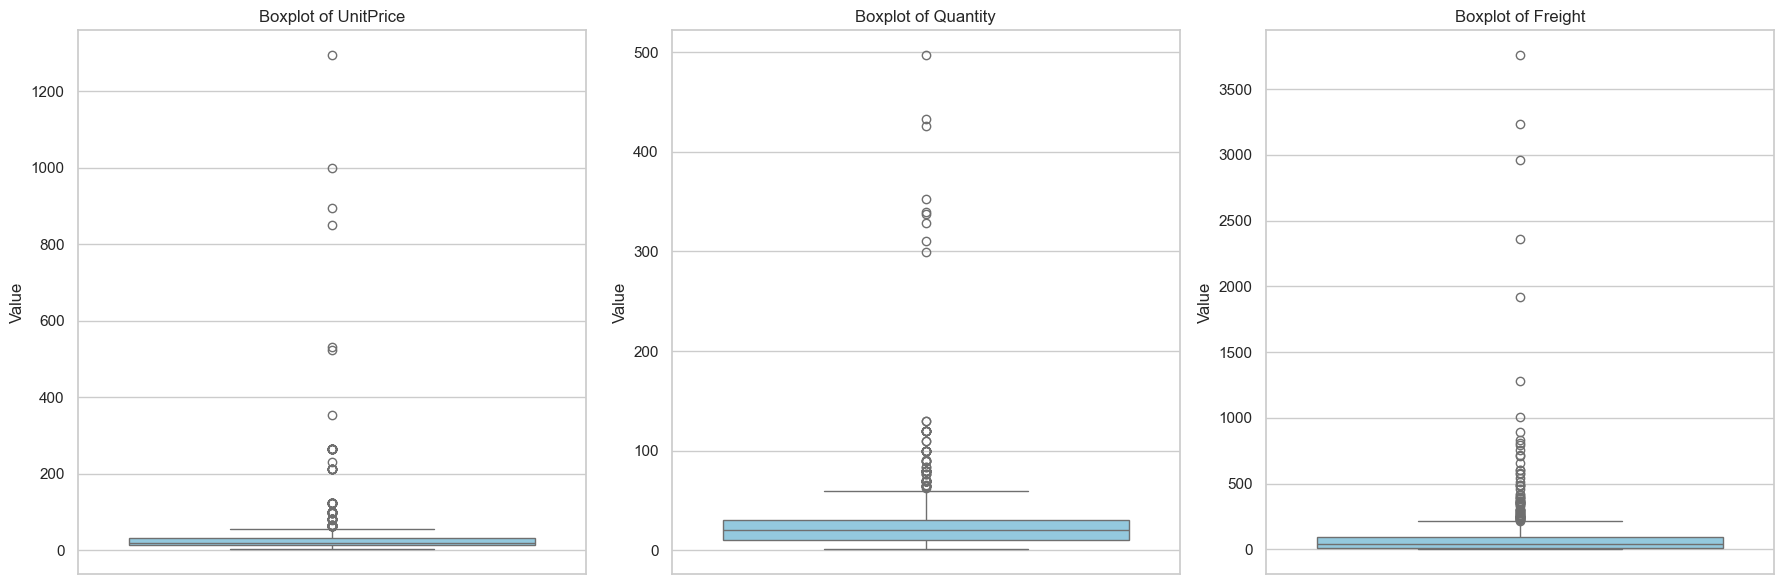

OUTLIER ANALYSIS COMPLETED SUCCESSFULLY



In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# تنظیم استایل بصری نمودارها
sns.set(style="whitegrid")

# تعریف لیست ستون‌های هدف برای بررسی داده‌های پرت
outlier_targets = [
    ('Order_Details', 'UnitPrice'),
    ('Order_Details', 'Quantity'),
    ('Orders', 'Freight')
]

separator = "=" * 60
print(f"\n{separator}")
print("STARTING OUTLIER DETECTION & BOXPLOT VISUALIZATION")
print(f"{separator}\n")

# ایجاد فضای رسم برای ۳ نمودار کنار هم
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (table_name, col_name) in enumerate(outlier_targets):
    # استخراج داده‌های ستون مورد نظر
    data_series = datasets[table_name][col_name].dropna()
    
    # --- ۱. شناسایی داده‌های پرت با متد IQR ---
    Q1 = data_series.quantile(0.25)
    Q3 = data_series.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # شمارش تعداد داده‌های خارج از محدوده
    outliers = data_series[(data_series < lower_bound) | (data_series > upper_bound)]
    count = outliers.count()
    
    # --- ۲. رسم نمودار جعبه‌ای (Boxplot) ---
    sns.boxplot(y=data_series, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot of {col_name}')
    axes[i].set_ylabel('Value')
    
    # چاپ گزارش در کنسول
    print(f" -> Table: {table_name:<13} | Column: {col_name:<10}")
    print(f"    IQR: {IQR:>7.2f} | Bounds: [{lower_bound:>7.2f}, {upper_bound:>7.2f}]")
    print(f"    Detected Outliers: {count} rows.\n")

# نمایش نهایی نمودارها
plt.tight_layout()
plt.show()

print(f"{separator}")
print("OUTLIER ANALYSIS COMPLETED SUCCESSFULLY")
print(f"{separator}\n")


In [82]:
print("\n--- 2. Outliers Count (IQR Method) ---")

# ستون‌های مورد بررسی برای داده‌های پرت (IQR)
columns_to_check = [
    ('Order_Details', 'UnitPrice'),
    ('Order_Details', 'Quantity'),
    ('Order_Details', 'Discount'),
    ('Orders', 'Freight'),
    ('Products', 'UnitsInStock') , 
    ('Products', 'UnitsOnOrder'),
    ('Products', 'ReorderLevel'),
    ('Customer_Features', 'Total_Orders'),
    ('Customer_Features', 'Total_Spend')
]
for df_name, col_name in columns_to_check:
    if col_name in datasets[df_name].columns:
        # استخراج داده‌های ستون به صورت عددی و حذف مقادیر خالی
        data = pd.to_numeric(datasets[df_name][col_name], errors='coerce').dropna()
        
        # محاسبه چارک اول و سوم
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        
        # محاسبه دامنه بین چارکی
        IQR = Q3 - Q1
        
        # تعریف محدوده‌های پایین و بالا
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # شمارش داده‌های پرت
        outliers_count = data[(data < lower_bound) | (data > upper_bound)].count()
        
        print(f"Number of outliers in '{col_name}' ({df_name}): {outliers_count}")



--- 2. Outliers Count (IQR Method) ---
Number of outliers in 'UnitPrice' (Order_Details): 105
Number of outliers in 'Quantity' (Order_Details): 93
Number of outliers in 'Discount' (Order_Details): 0
Number of outliers in 'Freight' (Orders): 68
Number of outliers in 'UnitsInStock' (Products): 0
Number of outliers in 'UnitsOnOrder' (Products): 16
Number of outliers in 'ReorderLevel' (Products): 0
Number of outliers in 'Total_Orders' (Customer_Features): 3
Number of outliers in 'Total_Spend' (Customer_Features): 7


In [83]:
print("\n--- 3. Outliers Count (Z-Score Method) ---")

# ستون‌هایی که برای یافتن داده پرت بررسی می‌شوند
# ستون‌های مورد بررسی برای داده‌های پرت (IQR)
columns_to_check = [
    ('Order_Details', 'UnitPrice'),
    ('Order_Details', 'Quantity'),
    ('Order_Details', 'Discount'),
    ('Orders', 'Freight'),
    ('Products', 'UnitsInStock') , 
    ('Products', 'UnitsOnOrder'),
    ('Products', 'ReorderLevel'),
    ('Customer_Features', 'Total_Orders'),
    ('Customer_Features', 'Total_Spend')
]

# پردازش هر ستون
for df_name, col_name in columns_to_check:
    # اطمینان از وجود جدول و ستون
    if df_name in datasets and col_name in datasets[df_name].columns:
        try:
            # آماده‌سازی داده‌ها (تبدیل به عدد و حذف مقادیر خالی)
            data = pd.to_numeric(datasets[df_name][col_name], errors='coerce').dropna()
            
            if data.empty:
                print(f"Skipping '{col_name}' ({df_name}): No valid numeric data.")
                continue

            # محاسبه Z-Score
            data_mean = data.mean()
            data_std = data.std()
            z_scores = (data - data_mean) / data_std
            
            # شمارش داده‌های پرت (Z-Score > 3 یا < -3)
            outliers_count = data[np.abs(z_scores) > 3].count()
            
            print(f"Number of outliers in '{col_name}' ({df_name}) (Z-Score): {outliers_count}")

        except Exception as e:
            # مدیریت خطا در پردازش ستون
            print(f"Error processing '{col_name}' ({df_name}): {e}")
    else:
        # اعلام عدم وجود جدول یا ستون
        print(f"Skipped: '{col_name}' not found in '{df_name}'.")

print("\n--- Analysis Finished ---")



--- 3. Outliers Count (Z-Score Method) ---
Number of outliers in 'UnitPrice' (Order_Details) (Z-Score): 32
Number of outliers in 'Quantity' (Order_Details) (Z-Score): 19
Number of outliers in 'Discount' (Order_Details) (Z-Score): 0
Number of outliers in 'Freight' (Orders) (Z-Score): 8
Number of outliers in 'UnitsInStock' (Products) (Z-Score): 0
Number of outliers in 'UnitsOnOrder' (Products) (Z-Score): 2
Number of outliers in 'ReorderLevel' (Products) (Z-Score): 0
Number of outliers in 'Total_Orders' (Customer_Features) (Z-Score): 3
Number of outliers in 'Total_Spend' (Customer_Features) (Z-Score): 4

--- Analysis Finished ---


In [84]:
import numpy as np
import pandas as pd

print("\n--- 4. Outliers Comparison (IQR vs Z-Score) ---")

# تعریف لیست ستون‌ها و دیتافریم‌های مربوطه
columns_to_check = [
    ('Order_Details', 'UnitPrice'),
    ('Order_Details', 'Quantity'),
    ('Order_Details', 'Discount'),
    ('Orders', 'Freight'),
    ('Products', 'UnitsInStock') , 
    ('Products', 'UnitsOnOrder'),
    ('Products', 'ReorderLevel'),
    ('Customer_Features', 'Total_Orders'),
    ('Customer_Features', 'Total_Spend')
]

# لیستی برای ذخیره نتایج جهت ساخت جدول مقایسه‌ای
comparison_results = []

for df_name, col_name in columns_to_check:
    if df_name in datasets and col_name in datasets[df_name].columns:
        # استخراج داده‌ها و پاک‌سازی اولیه
        data = pd.to_numeric(datasets[df_name][col_name], errors='coerce').dropna()
        
        # --- محاسبه با روش IQR ---
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        iqr_outliers = data[(data < lower_bound) | (data > upper_bound)].count()
        
        # --- محاسبه با روش Z-Score ---
        z_scores = (data - data.mean()) / data.std()
        z_score_outliers = data[np.abs(z_scores) > 3].count()
        
        # افزودن به لیست نتایج
        comparison_results.append({
            'Table': df_name,
            'Column': col_name,
            'IQR_Outliers': iqr_outliers,
            'Z-Score_Outliers': z_score_outliers
        })

# تبدیل به دیتافریم برای نمایش زیباتر به شکل جدول
comparison_df = pd.DataFrame(comparison_results)
print(comparison_df.to_string(index=False))


--- 4. Outliers Comparison (IQR vs Z-Score) ---
            Table       Column  IQR_Outliers  Z-Score_Outliers
    Order_Details    UnitPrice           105                32
    Order_Details     Quantity            93                19
    Order_Details     Discount             0                 0
           Orders      Freight            68                 8
         Products UnitsInStock             0                 0
         Products UnitsOnOrder            16                 2
         Products ReorderLevel             0                 0
Customer_Features Total_Orders             3                 3
Customer_Features  Total_Spend             7                 4



--- 5. Outlier Capping (Percentile Method) ---
-> Column 'Freight' in Orders was capped: [1.4, 312.9]

Done! Outliers were handled.

Plotting the changes for Freight...


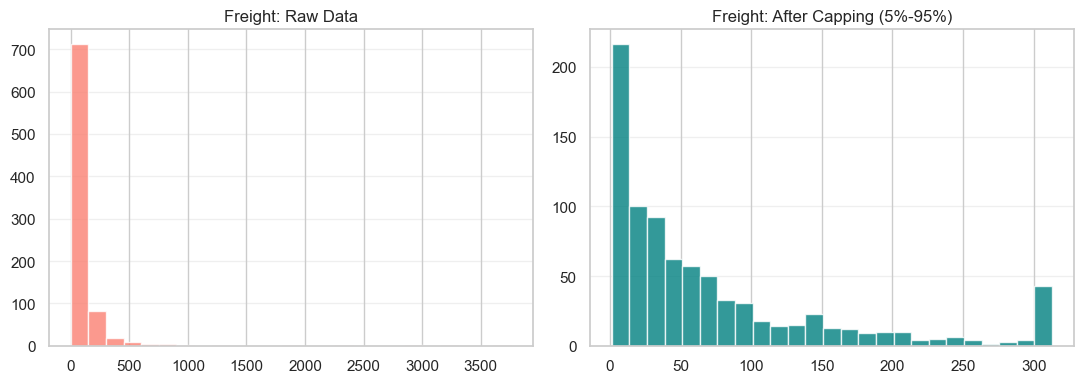

In [85]:
# --- مرحله ۵: مدیریت داده‌های پرت با روش برش (Capping) ---
print("\n--- 5. Outlier Capping (Percentile Method) ---")

# گرفتن کپی از داده‌های اصلی برای مقایسه در نمودار
old_freight = datasets['Orders']['Freight'].copy()

# لیست ستون‌هایی که باید اصلاح شوند
target_cols = [
    ('Orders', 'Freight'),
]

for table, col in target_cols:
    if table in datasets and col in datasets[table].columns:
        series = pd.to_numeric(datasets[table][col], errors='coerce')
        
        # محاسبه چارک‌های ۵ و ۹۵ درصد
        low = series.quantile(0.05)
        high = series.quantile(0.95)
        
        # جایگزینی مقادیر خارج از محدوده با استفاده از کلایپ
        datasets[table][col] = series.clip(low, high)
        
        print(f"-> Column '{col}' in {table} was capped: [{low:.1f}, {high:.1f}]")

print("\nDone! Outliers were handled.")

# --- رسم هیستوگرام مقایسه‌ای برای ستون Freight ---
print("\nPlotting the changes for Freight...")

new_freight = datasets['Orders']['Freight']

# ایجاد قاب برای ۲ نمودار
plt.figure(figsize=(11, 4))

# ۱. نمودار داده‌های خام (قبل)
plt.subplot(1, 2, 1)
plt.hist(old_freight.dropna(), bins=25, color='salmon', alpha=0.8)
plt.title('Freight: Raw Data')
plt.grid(axis='y', alpha=0.3)

# ۲. نمودار داده‌های اصلاح شده (بعد)
plt.subplot(1, 2, 2)
plt.hist(new_freight.dropna(), bins=25, color='teal', alpha=0.8)
plt.title('Freight: After Capping (5%-95%)')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


Limit: 60.0
High quantity orders: 93
Yes, high-quantity orders exist.

Top 10 highest Quantity values:
75      497
1754    433
1509    426
378     353
1477    340
1402    338
2139    328
523     310
1171    299
2104    130


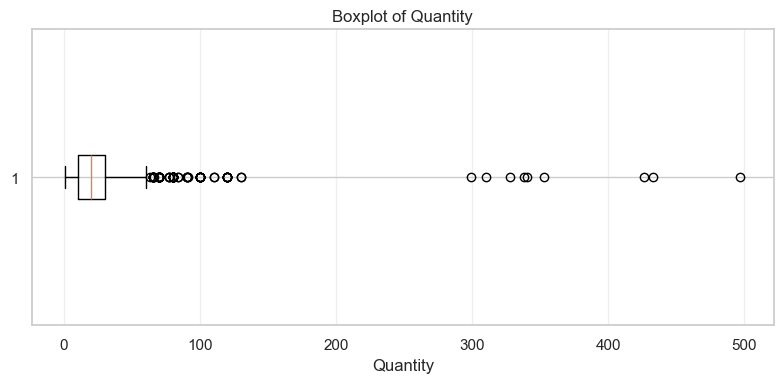

In [86]:
# تبدیل ستون Quantity به عدد
quantity = pd.to_numeric(datasets['Order_Details']['Quantity'], errors='coerce')

# محاسبه چارک اول، چارک سوم و IQR
q1 = quantity.quantile(0.25)
q3 = quantity.quantile(0.75)
iqr = q3 - q1

# تعیین حد بالای داده‌های نرمال
limit = q3 + 1.5 * iqr

# شناسایی سفارش‌هایی که Quantity آن‌ها از حد نرمال بیشتر است
outliers = quantity > limit

# نمایش نتایج بررسی
print("Limit:", limit)
print("High quantity orders:", outliers.sum())

if outliers.sum() > 0:
    print("Yes, high-quantity orders exist.")
else:
    print("No high-quantity orders found.")

# نمایش 10 مقدار بزرگ‌تر Quantity
top_10 = quantity.dropna().sort_values(ascending=False).head(10)
print("\nTop 10 highest Quantity values:")
print(top_10.to_string())

# رسم نمودار جعبه‌ای برای بررسی دیداری داده‌های پرت
plt.figure(figsize=(8, 4))
plt.boxplot(quantity.dropna(), vert=False)
plt.title("Boxplot of Quantity")
plt.xlabel("Quantity")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


Lower limit: -18.550000000000004
Upper limit: 68.25
Low-price outliers: 0
High-price outliers: 8
Yes, products with abnormal prices exist.

Top 10 highest product prices:
57    583.00
4     576.45
61    353.00
37    263.50
12    240.00
28    123.79
8      97.00
19     81.00
17     62.50
58     55.00

Top 10 lowest product prices:
32    2.50
23    4.50
51    7.00
53    7.45
74    7.75
22    9.00
18    9.20
46    9.50
44    9.50
40    9.65


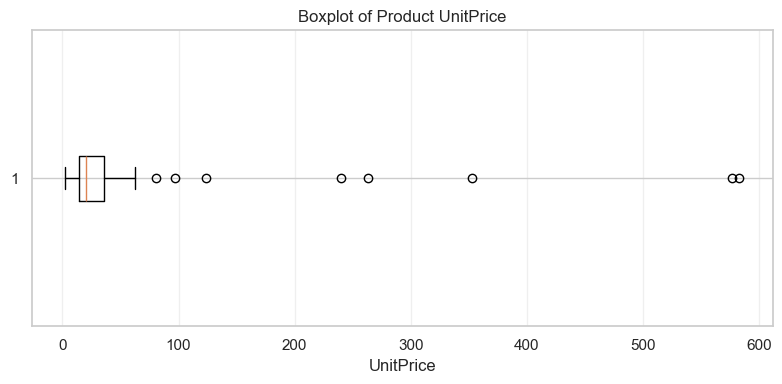

In [87]:
# تبدیل ستون UnitPrice در جدول Products به عدد
price = pd.to_numeric(datasets['Products']['UnitPrice'], errors='coerce')

# محاسبه چارک اول، چارک سوم و IQR
q1 = price.quantile(0.25)
q3 = price.quantile(0.75)
iqr = q3 - q1

# تعیین حد پایین و حد بالای داده‌های نرمال
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

# شناسایی محصولاتی که قیمت آن‌ها غیرعادی پایین یا بالا است
low_price_outliers = price < lower_limit
high_price_outliers = price > upper_limit

# نمایش نتایج بررسی
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)
print("Low-price outliers:", low_price_outliers.sum())
print("High-price outliers:", high_price_outliers.sum())

if low_price_outliers.sum() > 0 or high_price_outliers.sum() > 0:
    print("Yes, products with abnormal prices exist.")
else:
    print("No abnormal product prices found.")

# نمایش 10 قیمت بالای محصولات
top_10_prices = price.dropna().sort_values(ascending=False).head(10)
print("\nTop 10 highest product prices:")
print(top_10_prices.to_string())

# نمایش 10 قیمت پایین محصولات
bottom_10_prices = price.dropna().sort_values(ascending=True).head(10)
print("\nTop 10 lowest product prices:")
print(bottom_10_prices.to_string())

# رسم نمودار جعبه‌ای برای بررسی دیداری قیمت محصولات
plt.figure(figsize=(8, 4))
plt.boxplot(price.dropna(), vert=False)
plt.title("Boxplot of Product UnitPrice")
plt.xlabel("UnitPrice")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


In [88]:
import pandas as pd

# پیدا کردن اسم واقعی ستون‌ها
customer_cols = datasets['Customer_Features'].columns

total_orders_col = None
total_spending_col = None

for col in customer_cols:
    if col.lower().replace('_', '') == 'totalorders':
        total_orders_col = col
    if col.lower().replace('_', '') in ['totalspending', 'totalspend']:
        total_spending_col = col

# ستون‌هایی که باید بررسی شوند
columns_to_check = [
    ('Order_Details', 'UnitPrice'),
    ('Order_Details', 'Quantity'),
    ('Order_Details', 'Discount'),
    ('Orders', 'Freight'),
    ('Products', 'UnitsInStock'),
    ('Products', 'UnitsOnOrder'),
    ('Products', 'ReorderLevel')
]

# اضافه کردن ستون‌های Customer_Features فقط اگر واقعاً وجود داشته باشند
if total_orders_col is not None:
    columns_to_check.append(('Customer_Features', total_orders_col))

if total_spending_col is not None:
    columns_to_check.append(('Customer_Features', total_spending_col))

# لیست برای ذخیره نتایج
outlier_results = []

# بررسی هر ستون
for table_name, col_name in columns_to_check:

    # اگر جدول یا ستون وجود نداشت، رد شود
    if table_name not in datasets or col_name not in datasets[table_name].columns:
        outlier_results.append({
            'Table': table_name,
            'Column': col_name,
            'Mean Before': None,
            'Std Before': None,
            'Mean After': None,
            'Std After': None,
            'Change in Mean': None,
            'Change in Std': None,
            'Removed Outliers': 'Column Not Found'
        })
        continue

    # تبدیل داده‌ها به عدد و حذف مقدارهای خالی
    values = pd.to_numeric(datasets[table_name][col_name], errors='coerce').dropna()

    # اگر داده عددی معتبر وجود نداشت
    if len(values) == 0:
        outlier_results.append({
            'Table': table_name,
            'Column': col_name,
            'Mean Before': None,
            'Std Before': None,
            'Mean After': None,
            'Std After': None,
            'Change in Mean': None,
            'Change in Std': None,
            'Removed Outliers': 0
        })
        continue

    # محاسبه IQR
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    # داده‌های بدون پرت
    values_without_outliers = values[
        (values >= lower_limit) & (values <= upper_limit)
    ]

    # ذخیره نتیجه
    outlier_results.append({
        'Table': table_name,
        'Column': col_name,
        'Mean Before': values.mean(),
        'Std Before': values.std(),
        'Mean After': values_without_outliers.mean(),
        'Std After': values_without_outliers.std(),
        'Change in Mean': values_without_outliers.mean() - values.mean(),
        'Change in Std': values_without_outliers.std() - values.std(),
        'Removed Outliers': len(values) - len(values_without_outliers)
    })

# تبدیل نتایج به دیتافریم
outlier_summary = pd.DataFrame(outlier_results)

# نمایش خروجی
print(outlier_summary)


               Table        Column   Mean Before    Std Before    Mean After  \
0      Order_Details     UnitPrice     28.755201     55.247172     21.314565   
1      Order_Details      Quantity     25.198598     29.537930     21.283341   
2      Order_Details      Discount      0.055645      0.083196      0.055645   
3             Orders       Freight     72.147612     82.839342     52.688050   
4           Products  UnitsInStock     39.487179     36.643861     39.487179   
5           Products  UnitsOnOrder      9.871795     23.046739      0.000000   
6           Products  ReorderLevel     12.435897     10.863486     12.435897   
7  Customer_Features  Total_Orders      9.200000      5.781023      8.505747   
8  Customer_Features   Total_Spend  17260.301889  25127.658545  11215.632771   

      Std After  Change in Mean  Change in Std  Removed Outliers  
0     12.869807       -7.440636     -42.377365               105  
1     14.283912       -3.915257     -15.254018                93 

In [89]:
import pandas as pd

# اگر قبلاً برای UnitsOnOrder فلگ ساخته شده، حذف شود
if 'UnitsOnOrder_IsOutlier' in datasets['Products'].columns:
    datasets['Products'].drop(columns=['UnitsOnOrder_IsOutlier'], inplace=True)

# تابع برای پیدا کردن اسم واقعی ستون‌ها با درنظر گرفتن تفاوت _ و حروف
def find_column(df, possible_names):
    clean_cols = {col.lower().replace('_', ''): col for col in df.columns}
    
    for name in possible_names:
        clean_name = name.lower().replace('_', '')
        if clean_name in clean_cols:
            return clean_cols[clean_name]
    
    return None

# پیدا کردن اسم واقعی ستون‌های Customer_Features
customer_df = datasets['Customer_Features']

total_orders_col = find_column(customer_df, ['TotalOrders', 'Total_Orders'])
total_spending_col = find_column(customer_df, ['TotalSpending', 'Total_Spending', 'TotalSpend', 'Total_Spend'])

# مشخص کردن جدول‌ها و ستون‌هایی که باید از نظر داده پرت بررسی شوند
outlier_config = {
    'Order_Details': ['UnitPrice', 'Quantity', 'Discount'],
    'Orders': ['Freight'],
    'Products': ['UnitsInStock', 'ReorderLevel']
}

# اضافه کردن ستون‌های Customer_Features فقط اگر واقعاً پیدا شوند
outlier_config['Customer_Features'] = []

if total_orders_col is not None:
    outlier_config['Customer_Features'].append(total_orders_col)

if total_spending_col is not None:
    outlier_config['Customer_Features'].append(total_spending_col)

# لیست برای ذخیره خلاصه نتایج
outlier_summary = []

# بررسی داده‌های پرت
for table_name, columns in outlier_config.items():

    df = datasets[table_name]

    for column in columns:

        values = pd.to_numeric(df[column], errors='coerce')
        valid_values = values.dropna()

        if len(valid_values) == 0:
            outlier_summary.append({
                'Table': table_name,
                'Column': column,
                'Lower Bound': None,
                'Upper Bound': None,
                'Outlier Count': 0,
                'Outlier Percent': 0,
                'Decision': 'No valid numeric data'
            })
            continue

        q1 = valid_values.quantile(0.25)
        q3 = valid_values.quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        flag_column = f'{column}_IsOutlier'

        df[flag_column] = (values < lower_bound) | (values > upper_bound)

        outlier_count = df[flag_column].sum()
        total_count = valid_values.shape[0]
        outlier_percent = (outlier_count / total_count) * 100

        outlier_summary.append({
            'Table': table_name,
            'Column': column,
            'Lower Bound': lower_bound,
            'Upper Bound': upper_bound,
            'Outlier Count': outlier_count,
            'Outlier Percent': outlier_percent,
            'Decision': 'Flagged and retained'
        })

# اگر ستون‌های Customer_Features پیدا نشدند، در گزارش ثبت شوند
if total_orders_col is None:
    outlier_summary.append({
        'Table': 'Customer_Features',
        'Column': 'TotalOrders',
        'Lower Bound': None,
        'Upper Bound': None,
        'Outlier Count': None,
        'Outlier Percent': None,
        'Decision': 'Column Not Found'
    })

if total_spending_col is None:
    outlier_summary.append({
        'Table': 'Customer_Features',
        'Column': 'TotalSpending',
        'Lower Bound': None,
        'Upper Bound': None,
        'Outlier Count': None,
        'Outlier Percent': None,
        'Decision': 'Column Not Found'
    })

# تبدیل نتایج به دیتافریم
outlier_summary_df = pd.DataFrame(outlier_summary)

# نمایش گزارش
outlier_summary_df


,Table,Column,Lower Bound,Upper Bound,Outlier Count,Outlier Percent,Decision
0,Order_Details,UnitPrice,-18.0000,62.0000,105,4.906542,Flagged and retained
1,Order_Details,Quantity,-20.0000,60.0000,93,4.345794,Flagged and retained
2,Order_Details,Discount,-0.1500,0.2500,0,0.000000,Flagged and retained
3,Orders,Freight,-109.3700,217.9900,68,8.143713,Flagged and retained
4,Products,UnitsInStock,-54.3750,128.6250,0,0.000000,Flagged and retained
5,Products,ReorderLevel,-35.6250,59.3750,0,0.000000,Flagged and retained
6,Customer_Features,Total_Orders,-5.1250,21.8750,3,3.333333,Flagged and retained
7,Customer_Features,Total_Spend,-21852.5075,45005.8325,7,7.777778,Flagged and retained


In [90]:
# کپی از تمام دیتافریم‌ها قبل از شروع پاکسازی
datasets_before = {}

for name, df in datasets.items():
    datasets_before[name] = df.copy(deep=True)

print("Backup created for all DataFrames before cleaning.")
print("Tables copied:", list(datasets_before.keys()))


Backup created for all DataFrames before cleaning.
Tables copied: ['Orders', 'Order_Details', 'Products', 'Suppliers', 'Categories', 'Customer_Features']


In [91]:
# تبدیل ستون‌های تاریخی به فرمت تاریخ
order_dates = pd.to_datetime(datasets['Orders']['OrderDate'], errors='coerce')
shipped_dates = pd.to_datetime(datasets['Orders']['ShippedDate'], errors='coerce')
required_dates = pd.to_datetime(datasets['Orders']['RequiredDate'], errors='coerce')

# بررسی اینکه تاریخ ارسال قبل از تاریخ سفارش نباشد
invalid_ship_order = shipped_dates < order_dates

# بررسی اینکه تاریخ موردنیاز قبل از تاریخ سفارش نباشد
invalid_required_order = required_dates < order_dates

# بررسی اینکه تاریخ ارسال بعد از تاریخ موردنیاز نباشد
invalid_ship_required = shipped_dates > required_dates

# نمایش تعداد خطاها
print("Orders with ShippedDate earlier than OrderDate:", invalid_ship_order.sum())
print("Orders with RequiredDate earlier than OrderDate:", invalid_required_order.sum())
print("Orders with ShippedDate later than RequiredDate:", invalid_ship_required.sum())

# اگر خواستی ردیف‌های دارای مشکل را هم ببینی
problem_orders = datasets['Orders'][
    invalid_ship_order | invalid_required_order | invalid_ship_required
]

print("\nRows with invalid date sequence:")
print(problem_orders.head(10))


Orders with ShippedDate earlier than OrderDate: 59
Orders with RequiredDate earlier than OrderDate: 55
Orders with ShippedDate later than RequiredDate: 89

Rows with invalid date sequence:
    OrderID CustomerID  EmployeeID   OrderDate RequiredDate ShippedDate  \
2     10250      HANAR           4  1996-07-08   1996-05-08  1996-07-12   
3     10251      VICTE           3  1996-08-07   1996-08-05  1996-07-15   
4     10252      SUPRD           4  1996-07-09   1996-06-08  1996-07-11   
5     10253      HANAR           3  1996-10-07   1996-07-24  1996-07-16   
16    10264      FOLKO           6  1996-07-24   1996-08-21  1996-08-23   
19    10267      FRANK           4  2026-01-01   1996-08-26  1996-08-06   
20    10268      GROSR           8  1996-07-30   1996-08-27  1996-02-08   
23    10271      SPLIR           6  1996-01-08   1996-08-29  1996-08-30   
27    10275      MAGAA           1  1996-08-07   1996-04-09  1996-08-09   
32    10280      BERGS           2  1996-08-14   1996-09-11  

In [92]:
# انتخاب جدول سفارش‌ها برای ساده‌تر شدن کدنویسی
orders = datasets['Orders']

# تبدیل ستون‌های تاریخی به نوع datetime
# مقدارهای نامعتبر یا غیرقابل تبدیل به NaT تبدیل می‌شوند
orders['OrderDate'] = pd.to_datetime(orders['OrderDate'], errors='coerce')
orders['ShippedDate'] = pd.to_datetime(orders['ShippedDate'], errors='coerce')
orders['RequiredDate'] = pd.to_datetime(orders['RequiredDate'], errors='coerce')

# شناسایی سفارش‌هایی که تاریخ ارسال آن‌ها قبل از تاریخ ثبت سفارش است
mask_ship_before_order = orders['ShippedDate'] < orders['OrderDate']

# شناسایی سفارش‌هایی که تاریخ موردنیاز آن‌ها قبل از تاریخ ثبت سفارش است
mask_required_before_order = orders['RequiredDate'] < orders['OrderDate']

# شمارش تعداد خطاهای مربوط به تاریخ ارسال قبل از سفارش
invalid_ship_order = mask_ship_before_order.sum()

# شمارش تعداد خطاهای مربوط به تاریخ موردنیاز قبل از سفارش
invalid_required_order = mask_required_before_order.sum()

# نامعتبر کردن تاریخ ارسال‌هایی که قبل از تاریخ سفارش ثبت شده‌اند
orders.loc[mask_ship_before_order, 'ShippedDate'] = pd.NaT

# نامعتبر کردن تاریخ‌های موردنیازی که قبل از تاریخ سفارش ثبت شده‌اند
orders.loc[mask_required_before_order, 'RequiredDate'] = pd.NaT

# ایجاد ستون برای مشخص کردن سفارش‌هایی که دیرتر از موعد موردنیاز ارسال شده‌اند
orders['Late_Shipment'] = orders['ShippedDate'] > orders['RequiredDate']

# محاسبه تعداد روزهای تأخیر در ارسال
# اگر تأخیری وجود نداشته باشد، مقدار منفی به صفر تبدیل می‌شود
orders['Delay_Days'] = (
    orders['ShippedDate'] - orders['RequiredDate']
).dt.days.clip(lower=0)

# نمایش پیام تکمیل فرایند پاک‌سازی تاریخ‌ها
print("Date cleaning completed.")

# نمایش تعداد تاریخ‌های ارسال نامعتبر که اصلاح شده‌اند
print("ShippedDate earlier than OrderDate fixed:", invalid_ship_order)

# نمایش تعداد تاریخ‌های موردنیاز نامعتبر که اصلاح شده‌اند
print("RequiredDate earlier than OrderDate fixed:", invalid_required_order)

# نمایش تعداد سفارش‌هایی که با تأخیر ارسال شده‌اند
print("Late shipments detected:", orders['Late_Shipment'].sum())


Date cleaning completed.
ShippedDate earlier than OrderDate fixed: 59
RequiredDate earlier than OrderDate fixed: 55
Late shipments detected: 60


In [93]:
# استخراج شناسه سفارش‌ها از دو جدول
detail_order_ids = datasets['Order_Details']['OrderID']
orders_order_ids = datasets['Orders']['OrderID']

# پیدا کردن OrderIDهایی که در جزئیات سفارش هستند ولی در جدول Orders وجود ندارند
invalid_order_ids = detail_order_ids[~detail_order_ids.isin(orders_order_ids)]

# نمایش نتیجه
print("Number of invalid OrderID values in Order_Details:", invalid_order_ids.nunique())

if invalid_order_ids.nunique() > 0:
    print("Some OrderID values in Order_Details do not exist in Orders.")
    print("Sample invalid OrderIDs:")
    print(invalid_order_ids.drop_duplicates().head(10).to_string(index=False))
else:
    print("All OrderID values in Order_Details exist in Orders.")


Number of invalid OrderID values in Order_Details: 1
Some OrderID values in Order_Details do not exist in Orders.
Sample invalid OrderIDs:
99999


In [94]:
# تعداد ردیف‌ها قبل از اصلاح
before_rows = len(datasets['Order_Details'])

# نگه داشتن فقط OrderIDهایی که در جدول Orders وجود دارند
datasets['Order_Details'] = datasets['Order_Details'][
    datasets['Order_Details']['OrderID'].isin(datasets['Orders']['OrderID'])
]

# تعداد ردیف‌ها بعد از اصلاح
after_rows = len(datasets['Order_Details'])

# تعداد ردیف‌های حذف‌شده
removed_rows = before_rows - after_rows

# نمایش نتیجه
print("Referential integrity cleaning completed.")
print("Removed rows from Order_Details:", removed_rows)
print("Remaining rows in Order_Details:", after_rows)


Referential integrity cleaning completed.
Removed rows from Order_Details: 2
Remaining rows in Order_Details: 2138


In [95]:
# بررسی ستون‌هایی که از نظر منطقی نباید مقدار نامعتبر داشته باشند
print("Checking logically invalid values...")

# تعداد سفارش باید بزرگ‌تر از صفر باشد
invalid_quantity = datasets['Order_Details'][
    datasets['Order_Details']['Quantity'] <= 0
]

print("Invalid Quantity rows:", len(invalid_quantity))


# تخفیف باید بین 0 و 1 باشد
invalid_discount = datasets['Order_Details'][
    (datasets['Order_Details']['Discount'] < 0) |
    (datasets['Order_Details']['Discount'] > 1)
]

print("Invalid Discount rows:", len(invalid_discount))


# قیمت واحد نباید منفی باشد
invalid_unitprice_orderdetails = datasets['Order_Details'][
    datasets['Order_Details']['UnitPrice'] < 0
]

print("Invalid UnitPrice in Order_Details:", len(invalid_unitprice_orderdetails))


# هزینه حمل نباید منفی باشد
invalid_freight = datasets['Orders'][
    datasets['Orders']['Freight'] < 0
]

print("Invalid Freight rows:", len(invalid_freight))


# موجودی کالا نباید منفی باشد
invalid_stock = datasets['Products'][
    datasets['Products']['UnitsInStock'] < 0
]

print("Invalid UnitsInStock rows:", len(invalid_stock))


# قیمت محصول نباید منفی باشد
invalid_product_price = datasets['Products'][
    datasets['Products']['UnitPrice'] < 0
]

print("Invalid Product UnitPrice rows:", len(invalid_product_price))


Checking logically invalid values...
Invalid Quantity rows: 0
Invalid Discount rows: 0
Invalid UnitPrice in Order_Details: 0
Invalid Freight rows: 0
Invalid UnitsInStock rows: 0
Invalid Product UnitPrice rows: 0


In [96]:
# بررسی اینکه مقدار Discount بین 0 و 1 باشد
invalid_discount = datasets['Order_Details'][
    (datasets['Order_Details']['Discount'] < 0) |
    (datasets['Order_Details']['Discount'] > 1)
]

print("Number of invalid Discount values:", len(invalid_discount))
print(invalid_discount[['OrderID', 'ProductID', 'Discount']].head())


Number of invalid Discount values: 0
Empty DataFrame
Columns: [OrderID, ProductID, Discount]
Index: []


In [97]:
# اگر جدول Categories در datasets وجود داشته باشد
if 'Categories' in datasets:
    
    # پیدا کردن محصولاتی که CategoryID آن‌ها در جدول Categories وجود ندارد
    invalid_category = datasets['Products'][
        ~datasets['Products']['CategoryID'].isin(datasets['Categories']['CategoryID'])
    ]

    # نمایش تعداد محصولات با CategoryID نامعتبر
    print("Number of products with invalid CategoryID:", len(invalid_category))
    
    # نمایش چند سطر اول از محصولات نامعتبر
    print(invalid_category[['ProductID', 'ProductName', 'CategoryID']].head())

# اگر جدول Categories هنوز فراخوانی نشده باشد
else:
    
    # نمایش پیام خطا
    print("Table 'Categories' not found in datasets.")
    
    # نمایش نام جدول‌های موجود
    print("Available tables:", list(datasets.keys()))


Number of products with invalid CategoryID: 1
    ProductID ProductName  CategoryID
77          1        Chai          99


In [98]:
# اگر جدول Categories در datasets وجود داشته باشد
if 'Categories' in datasets:
    
    # تعداد ردیف‌های Products قبل از اصلاح
    before_rows = len(datasets['Products'])
    
    # نگه داشتن فقط محصولاتی که CategoryID معتبر دارند
    datasets['Products'] = datasets['Products'][
        datasets['Products']['CategoryID'].isin(datasets['Categories']['CategoryID'])
    ]
    
    # تعداد ردیف‌های Products بعد از اصلاح
    after_rows = len(datasets['Products'])
    
    # تعداد ردیف‌های حذف‌شده
    removed_rows = before_rows - after_rows
    
    print("CategoryID referential integrity cleaning completed.")
    print("Removed rows from Products:", removed_rows)
    print("Remaining rows in Products:", after_rows)

# اگر جدول Categories وجود نداشته باشد
else:
    print("Table 'Categories' not found in datasets.")
    print("Available tables:", list(datasets.keys()))


CategoryID referential integrity cleaning completed.
Removed rows from Products: 1
Remaining rows in Products: 77


In [99]:
def find_invalid_records(data, database_name):
    # لیست برای نگهداری رکوردهای نامعتبر
    invalid_rows = []

    # لیست برای نگهداری خلاصه نتایج اعتبارسنجی
    summary_rows = []

    def add_invalid(table_name, rule_name, df, condition):
        # استخراج رکوردهایی که شرط خطا را دارند
        invalid_df = df[condition].copy()

        # ثبت خلاصه نتیجه برای هر قانون اعتبارسنجی
        summary_rows.append({
            'Database': database_name,
            'Table': table_name,
            'Rule': rule_name,
            'Total Rows': len(df),
            'Invalid Count': len(invalid_df)
        })

        # در صورت وجود رکورد نامعتبر، اطلاعات تکمیلی به آن اضافه می‌شود
        if len(invalid_df) > 0:
            invalid_df['Database'] = database_name
            invalid_df['Table'] = table_name
            invalid_df['Rule'] = rule_name
            invalid_df['Original_Index'] = invalid_df.index

            invalid_rows.append(invalid_df)
    # =========================
    # اعتبارسنجی جدول Orders
    # =========================
    if 'Orders' in data:
        orders = data['Orders']

        # تبدیل ستون‌های تاریخ به فرمت datetime برای مقایسه درست
        order_date = pd.to_datetime(orders['OrderDate'], errors='coerce') if 'OrderDate' in orders.columns else None
        shipped_date = pd.to_datetime(orders['ShippedDate'], errors='coerce') if 'ShippedDate' in orders.columns else None
        required_date = pd.to_datetime(orders['RequiredDate'], errors='coerce') if 'RequiredDate' in orders.columns else None

        # بررسی اینکه تاریخ ارسال قبل از تاریخ سفارش نباشد
        if {'ShippedDate', 'OrderDate'}.issubset(orders.columns):
            condition = (
                shipped_date.notna() &
                order_date.notna() &
                (shipped_date < order_date)
            )

            add_invalid(
                'Orders',
                'ShippedDate < OrderDate',
                orders,
                condition
            )

        # بررسی اینکه تاریخ موردنیاز قبل از تاریخ سفارش نباشد
        if {'RequiredDate', 'OrderDate'}.issubset(orders.columns):
            condition = (
                required_date.notna() &
                order_date.notna() &
                (required_date < order_date)
            )

            add_invalid(
                'Orders',
                'RequiredDate < OrderDate',
                orders,
                condition
            )

        # بررسی اینکه تاریخ ارسال بعد از تاریخ موردنیاز نباشد
        if {'ShippedDate', 'RequiredDate'}.issubset(orders.columns):
            condition = (
                shipped_date.notna() &
                required_date.notna() &
                (shipped_date > required_date)
            )

            add_invalid(
                'Orders',
                'ShippedDate > RequiredDate',
                orders,
                condition
            )

        # بررسی منفی نبودن هزینه حمل
        if 'Freight' in orders.columns:
            condition = (
                orders['Freight'].notna() &
                (orders['Freight'] < 0)
            )

            add_invalid(
                'Orders',
                'Freight < 0',
                orders,
                condition
            )

    # =========================
    # اعتبارسنجی جدول Order_Details
    # =========================
    if 'Order_Details' in data:
        od = data['Order_Details']

        # بررسی مثبت بودن تعداد سفارش
        if 'Quantity' in od.columns:
            condition = (
                od['Quantity'].notna() &
                (od['Quantity'] <= 0)
            )

            add_invalid(
                'Order_Details',
                'Quantity <= 0',
                od,
                condition
            )

        # بررسی منفی نبودن قیمت واحد
        if 'UnitPrice' in od.columns:
            condition = (
                od['UnitPrice'].notna() &
                (od['UnitPrice'] < 0)
            )

            add_invalid(
                'Order_Details',
                'UnitPrice < 0',
                od,
                condition
            )

        # بررسی معتبر بودن مقدار تخفیف بین صفر و یک
        if 'Discount' in od.columns:
            condition = (
                od['Discount'].notna() &
                (
                    (od['Discount'] < 0) |
                    (od['Discount'] > 1)
                )
            )

            add_invalid(
                'Order_Details',
                'Discount not between 0 and 1',
                od,
                condition
            )

    # =========================
    # بررسی صحت ارتباط OrderID بین Orders و Order_Details
    # =========================
    if 'Orders' in data and 'Order_Details' in data:
        orders = data['Orders']
        od = data['Order_Details']

        # بررسی اینکه همه OrderIDهای جدول Order_Details در جدول Orders وجود داشته باشند
        if 'OrderID' in orders.columns and 'OrderID' in od.columns:
            condition = (
                od['OrderID'].notna() &
                ~od['OrderID'].isin(orders['OrderID'])
            )

            add_invalid(
                'Order_Details',
                'Invalid OrderID',
                od,
                condition
            )

    # =========================
    # اعتبارسنجی جدول Products
    # =========================
    if 'Products' in data:
        products = data['Products']

        # بررسی منفی نبودن موجودی انبار
        if 'UnitsInStock' in products.columns:
            condition = (
                products['UnitsInStock'].notna() &
                (products['UnitsInStock'] < 0)
            )

            add_invalid(
                'Products',
                'UnitsInStock < 0',
                products,
                condition
            )

        # بررسی منفی نبودن قیمت واحد محصول
        if 'UnitPrice' in products.columns:
            condition = (
                products['UnitPrice'].notna() &
                (products['UnitPrice'] < 0)
            )

            add_invalid(
                'Products',
                'Product UnitPrice < 0',
                products,
                condition
            )

    # =========================
    # بررسی صحت ارتباط CategoryID بین Products و Categories
    # =========================
    if 'Products' in data and 'Categories' in data:
        products = data['Products']
        categories = data['Categories']

        # بررسی اینکه همه CategoryIDهای جدول Products در جدول Categories وجود داشته باشند
        if 'CategoryID' in products.columns and 'CategoryID' in categories.columns:
            condition = (
                products['CategoryID'].notna() &
                ~products['CategoryID'].isin(categories['CategoryID'])
            )

            add_invalid(
                'Products',
                'Invalid CategoryID',
                products,
                condition
            )

    # ساخت دیتافریم خلاصه اعتبارسنجی‌ها
    summary_df = pd.DataFrame(summary_rows)

    # تجمیع تمام رکوردهای نامعتبر در یک دیتافریم
    if len(invalid_rows) > 0:
        invalid_records_df = pd.concat(invalid_rows, ignore_index=True, sort=False)
    else:
        invalid_records_df = pd.DataFrame()

    return summary_df, invalid_records_df


In [100]:
# اجرای تابع اعتبارسنجی روی داده‌های قبل از پاکسازی
before_summary, before_invalid_records = find_invalid_records(
    datasets_before,
    'Before Cleaning'
)

# نمایش خلاصه تعداد خطاها و رکوردهای نامعتبر در هر قانون
print("Summary before cleaning:")
print(before_summary)

# نمایش خودِ رکوردهای نامعتبر شناسایی‌شده
print("\nInvalid records before cleaning:")
print(before_invalid_records)


Summary before cleaning:
           Database          Table                          Rule  Total Rows  \
0   Before Cleaning         Orders       ShippedDate < OrderDate         835   
1   Before Cleaning         Orders      RequiredDate < OrderDate         835   
2   Before Cleaning         Orders    ShippedDate > RequiredDate         835   
3   Before Cleaning         Orders                   Freight < 0         835   
4   Before Cleaning  Order_Details                 Quantity <= 0        2140   
5   Before Cleaning  Order_Details                 UnitPrice < 0        2140   
6   Before Cleaning  Order_Details  Discount not between 0 and 1        2140   
7   Before Cleaning  Order_Details               Invalid OrderID        2140   
8   Before Cleaning       Products              UnitsInStock < 0          78   
9   Before Cleaning       Products         Product UnitPrice < 0          78   
10  Before Cleaning       Products            Invalid CategoryID          78   

    Invalid Co

In [101]:
# اجرای تابع اعتبارسنجی روی داده‌های بعد از پاکسازی
after_summary, after_invalid_records = find_invalid_records(
    datasets,
    'After Cleaning'
)

# نمایش خلاصه تعداد خطاها و رکوردهای نامعتبر پس از پاکسازی
print("Summary after cleaning:")
print(after_summary)

# نمایش رکوردهای نامعتبری که بعد از پاکسازی هنوز باقی مانده‌اند
print("\nInvalid records after cleaning:")
print(after_invalid_records)


Summary after cleaning:
          Database          Table                          Rule  Total Rows  \
0   After Cleaning         Orders       ShippedDate < OrderDate         835   
1   After Cleaning         Orders      RequiredDate < OrderDate         835   
2   After Cleaning         Orders    ShippedDate > RequiredDate         835   
3   After Cleaning         Orders                   Freight < 0         835   
4   After Cleaning  Order_Details                 Quantity <= 0        2138   
5   After Cleaning  Order_Details                 UnitPrice < 0        2138   
6   After Cleaning  Order_Details  Discount not between 0 and 1        2138   
7   After Cleaning  Order_Details               Invalid OrderID        2138   
8   After Cleaning       Products              UnitsInStock < 0          77   
9   After Cleaning       Products         Product UnitPrice < 0          77   
10  After Cleaning       Products            Invalid CategoryID          77   

    Invalid Count  
0      

In [102]:
for name, df in datasets.items():
    df.to_csv(folder_path + name + ".csv", index=False, encoding="utf-8-sig")
